# 项目背景  

京东作为中国最大的自营式电商，在保持高速发展的同时，沉淀了数亿的忠实用户，积累了海量的真实数据。如何从历史数据中找出规律，去预测用户未来的购买需求，让最合适的商品遇见最需要的人，是大数据应用在精准营销中的关键问题，也是所有电商平台在做智能化升级时所需要的核心技术。  
以京东商城真实的用户、商品和行为数据（脱敏后）为基础，通过数据挖掘的技术和机器学习的算法，构建用户购买商品的预测模型，输出高潜用户和目标商品的匹配结果，为精准营销提供高质量的目标群体。  

目标：使用京东多个品类下商品的历史销售数据，构建算法模型，预测用户在未来5天内，对某个目标品类下商品的购买意向。

<h2>数据集介绍</h2><ul><li><p>这里涉及到的数据集是京东最新的数据集：</p></li><li><p>JData_User.csv 用户数据集 105,321个用户</p></li><li><p>JData_Comment.csv 商品评论 558,552条记录</p></li><li><p>JData_Product.csv 预测商品集合 24,187条记录</p></li><li><p>JData_Action_201602.csv 2月份行为交互记录 11,485,424条记录</p></li><li><p>JData_Action_201603.csv 3月份行为交互记录 25,916,378条记录</p></li><li><p>JData_Action_201604.csv 4月份行为交互记录 13,199,934条记录</p></li></ul><p></p>

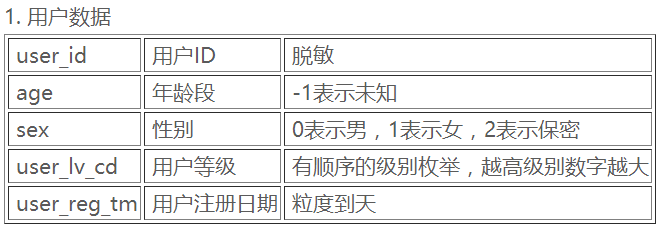

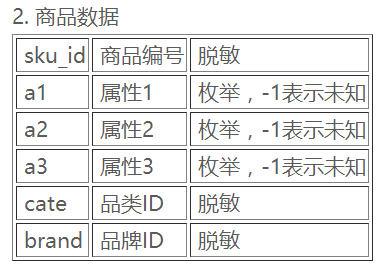

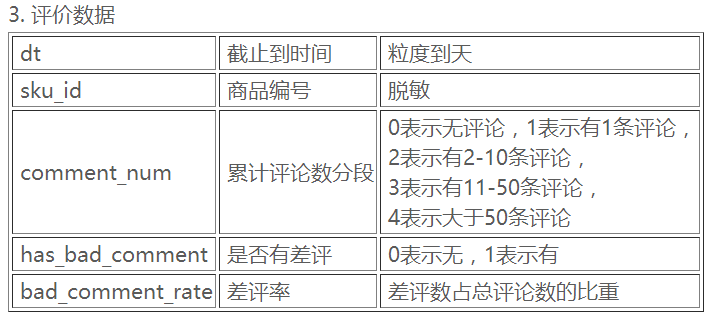

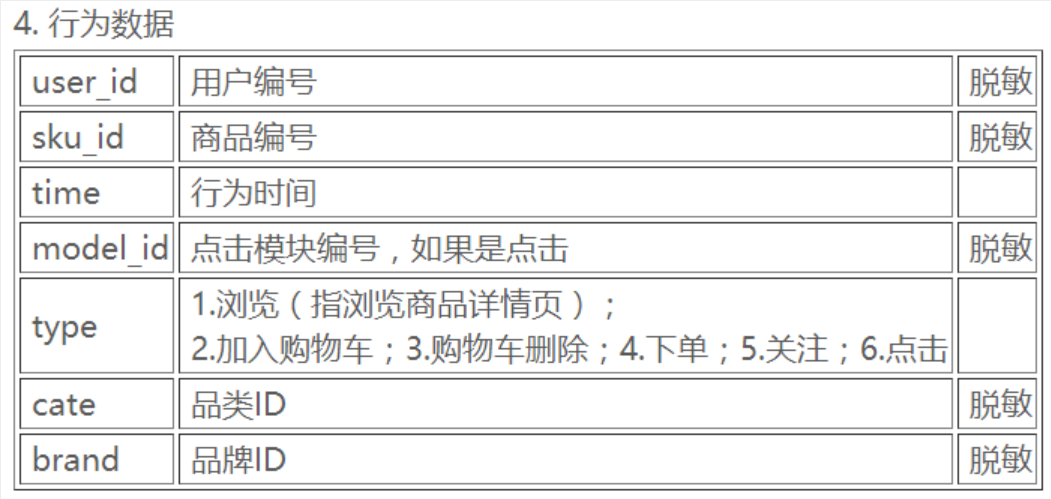

In [71]:
from IPython.display import Image
display(Image(r"D:\allsoft\模块数据\京东实战数据\用户数据介绍.png"),Image(r"D:\allsoft\模块数据\京东实战数据\商品数据介绍.png"),Image(r"D:\allsoft\模块数据\京东实战数据\评价数据介绍.png"),Image(r"D:\allsoft\模块数据\京东实战数据\行为数据介绍.png"))


## 数据挖掘流程：  
（一）、数据概览  

1. 数据集介绍  
2. 数据集一致性检验  
3. 数据集重复数据查看  

（二）、数据理解与分析  

1. 掌握各个特征的含义  

2. 观察数据有哪些特点，是否可利用来建模  

3. 可视化展示便于分析  

4. 用户的购买意向是否随着时间等因素变化  

（三）、特征提取  

1. 分别对用户与商品以及其之间构成的行为进行特征提取  

2. 筛选行为因素中的核心特征并进行提取  

3. 瞬时行为特征or累计行为特征提取  

（四）、模型建立  

1. 使用机器学习算法进行建模预测  

2. 超参数参数设置与调节 

## 数据一致性检验

首先检查JData_User中的用户和JData_Action中的用户是否一致   

保证行为数据中的所产生的行为均由用户数据中的用户产生（但是可能存在用户在行为数据中无行为）

思路：利用pd.Merge根据sku连接两个DataFrame, 观察数据是否减少: 

In [1]:
import pandas as pd
df1 = pd.DataFrame({'sku':['a','b','c','d'], # 4
                    'data':[1,1,2,3]})
df2 = pd.DataFrame({'sku':['a','b','f']}) # 3
df3 = pd.DataFrame({'sku':['a','b','d']})
df4 = pd.DataFrame({'sku':['a','b','c','d']})
display(pd.merge(df1,df2))
display(pd.merge(df1,df3))
display(pd.merge(df1,df4)) # 索引一致未减少

,sku,data
0,a,1
1,b,1


,sku,data
0,a,1
1,b,1
2,d,3


,sku,data
0,a,1
1,b,1
2,c,2
3,d,3


查看数据

In [2]:
df_user = pd.read_csv(r"D:\allsoft\模块数据\京东实战数据\JData_User.csv")
display(df_user.head())

df_month3 = pd.read_csv(r"D:\allsoft\模块数据\京东实战数据\JData_Action_201603.csv")
df_month3.head()

,user_id,age,sex,user_lv_cd,user_reg_tm
0,200001,6.0,2.0,5,2016-01-26
1,200002,-1.0,0.0,1,2016-01-26
2,200003,4.0,1.0,4,2016-01-26
3,200004,-1.0,2.0,1,2016-01-26
4,200005,2.0,0.0,4,2016-01-26


,user_id,sku_id,time,model_id,type,cate,brand
0,280567,167208,2016-02-29 23:59:01,0.0,6,4,519
1,270248,35533,2016-02-29 23:59:02,111.0,6,4,306
2,203360,78694,2016-02-29 23:59:02,NaN,1,8,244
3,252369,90402,2016-02-29 23:59:03,0.0,6,7,38
4,279590,154208,2016-02-29 23:59:03,0.0,6,5,570


查看数据内存

In [3]:
df_month3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25916378 entries, 0 to 25916377
Data columns (total 7 columns):
 #   Column    Dtype  
---  ------    -----  
 0   user_id   int64  
 1   sku_id    int64  
 2   time      object 
 3   model_id  float64
 4   type      int64  
 5   cate      int64  
 6   brand     int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 1.4+ GB


垃圾回收

In [4]:
import gc
del df_user
del df_month3
gc.collect()

0

利用pd.Merge根据user_id连接数据, 判断数据是否减少: 

In [5]:
def user_action_id_check():
    df_user = pd.read_csv(r"D:\allsoft\模块数据\京东实战数据\JData_User.csv")
    df_user = df_user.loc[:,'user_id'].to_frame()
    df_month2 = pd.read_csv(r"D:\allsoft\模块数据\京东实战数据\JData_Action_201602.csv")
    print ('Is action of Feb. from User file? ', 
           len(df_month2) == len(pd.merge(df_user,df_month2)))
    
    df_month3 = pd.read_csv(r"D:\allsoft\模块数据\京东实战数据\JData_Action_201603.csv")
    print ('Is action of Mar. from User file? ', len(df_month3) == len(pd.merge(df_user,df_month3)))
    df_month4 = pd.read_csv(r"D:\allsoft\模块数据\京东实战数据\JData_Action_201604.csv")
    print ('Is action of Apr. from User file? ', len(df_month4) == len(pd.merge(df_user,df_month4)))
    del df_user,df_month2,df_month3,df_month4
    gc.collect()
user_action_id_check()

Is action of Feb. from User file?  True
Is action of Mar. from User file?  True
Is action of Apr. from User file?  True


结论： User数据集中的用户和交互行为数据集中的用户完全一致  

根据merge前后的数据量比对，能保证Action中的用户ID是User中的ID的子集*

## 检查是否有重复记录  


In [9]:
def deduplicate(filepath, filename):
    df_file = pd.read_csv(filepath) 
    
    before = df_file.shape[0] # 原文件总数据量
    df_file.drop_duplicates(inplace=True) # 去重
    after = df_file.shape[0] #  去重后，数据量
    n_dup = before-after # 重复数据量
    if n_dup != 0:
        print ('No. of duplicate records for ' + filename + ' is: ' + str(n_dup))
    else:
        print ('no duplicate records in ' + filename)
    del df_file
    gc.collect()

检查每个数据文件重复数据

In [10]:
%%time
deduplicate(r"D:allsoft\模块数据\京东实战数据\JData_Action_201602.csv",'Feb. action')
deduplicate(r"D:allsoft\模块数据\京东实战数据\JData_Action_201603.csv", 'Mar. action')
deduplicate(r"D:allsoft\模块数据\京东实战数据\JData_Action_201604.csv", 'Apr. action')
deduplicate(r"D:allsoft\模块数据\京东实战数据\JData_Comment.csv", 'Comment')
deduplicate(r"D:allsoft\模块数据\京东实战数据\JData_Product.csv", 'Product')
deduplicate(r"D:allsoft\模块数据\京东实战数据\JData_User.csv", 'User')

No. of duplicate records for Feb. action is: 2756093
No. of duplicate records for Mar. action is: 7085037
No. of duplicate records for Apr. action is: 3672710
no duplicate records in Comment
no duplicate records in Product
no duplicate records in User
CPU times: total: 40.4 s
Wall time: 40.6 s


重复数据分析：

In [12]:
df_month3 = pd.read_csv(r"D:allsoft\模块数据\京东实战数据\JData_Action_201603.csv")
IsDuplicated = df_month3.duplicated() # boolean 重复，True，不然False

df_d=df_month3[IsDuplicated] # 取出来，重复数据
display(df_d.groupby('type').count()) # 统计计数

del df_month3,df_d
gc.collect()

,user_id,sku_id,time,model_id,cate,brand
type,,,,,,
1,4659616,4659616,4659616,0,4659616,4659616
2,1406,1406,1406,0,1406,1406
3,2360,2360,2360,0,2360,2360
4,39,39,39,0,39,39
5,4475,4475,4475,0,4475,4475
6,2417141,2417141,2417141,2355765,2417141,2417141


2020

结论发现，重复数据大多数都是由于浏览(1)，或者点击(6)产生   

重复数据是有意义的，比如用户同时购买多件商品，同时添加多个数量的商品到购物车等...

# 周各天购买量

## 导包定义文件变量

In [13]:
# 导入相关包
# 绘图包
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#定义文件名
ACTION_201602_FILE = r"D:\allsoft\模块数据\京东实战数据\JData_Action_201602.csv"
ACTION_201603_FILE = r"D:\allsoft\模块数据\京东实战数据\JData_Action_201603.csv"
ACTION_201604_FILE = r"D:\allsoft\模块数据\京东实战数据\JData_Action_201604.csv"
COMMENT_FILE = r"D:\allsoft\模块数据\京东实战数据\JData_Comment.csv"
PRODUCT_FILE = r"D:\allsoft\模块数据\京东实战数据\JData_Product.csv"
USER_FILE = r"D:\allsoft\模块数据\京东实战数据\JData_User.csv"

In [14]:
# 提取购买(type=4)的行为数据
def get_from_action_data(fname, chunk_size=50000):
    reader = pd.read_csv(fname, header=0, iterator=True)
    chunks = []
    loop = True
    while loop:
        try:
            chunk = reader.get_chunk(chunk_size)[
                ["user_id", "sku_id", "type", "time"]]
            chunks.append(chunk)
        except StopIteration:
            loop = False
            print("Iteration is stopped")

    df_ac = pd.concat(chunks, ignore_index=True)
    # type=4,为购买
    df_ac = df_ac[df_ac['type'] == 4]

    return df_ac[["user_id", "sku_id", "time"]]

## 提取全部购买数据(type=4)

In [15]:
df_ac = []
df_ac.append(get_from_action_data(fname=ACTION_201602_FILE))
display(df_ac)
df_ac.append(get_from_action_data(fname=ACTION_201603_FILE))
df_ac.append(get_from_action_data(fname=ACTION_201604_FILE))
df_ac = pd.concat(df_ac, ignore_index=True)
display(df_ac.head(),df_ac.shape)

Iteration is stopped


[          user_id  sku_id                 time
 351        269365  166345  2016-02-01 00:01:00
 649        235443   36692  2016-02-01 00:02:00
 980        247689    9112  2016-02-01 00:03:00
 1719       273959  102034  2016-02-01 00:05:00
 2153       226791  163550  2016-02-01 00:06:00
 ...           ...     ...                  ...
 11464511   256461  126092  2016-02-29 23:26:00
 11470852   224347  137636  2016-02-29 23:36:00
 11478541   300214  102335  2016-02-29 23:50:00
 11480871   213442   48000  2016-02-29 23:54:00
 11483928   228994  165190  2016-02-29 23:58:00
 
 [11485 rows x 3 columns]]

Iteration is stopped
Iteration is stopped


,user_id,sku_id,time
0,269365,166345,2016-02-01 00:01:00
1,235443,36692,2016-02-01 00:02:00
2,247689,9112,2016-02-01 00:03:00
3,273959,102034,2016-02-01 00:05:00
4,226791,163550,2016-02-01 00:06:00


(48252, 3)

In [16]:
df_ac.dtypes

user_id     int64
sku_id      int64
time       object
dtype: object

## 日期转换

In [17]:
# 将time字段转换为datetime类型
df_ac['time']=pd.to_datetime(df_ac['time'])
display(df_ac.head(),df_ac.dtypes)
# 使用lambda函数将时间time转化为星期(周一为1,周日为7)
df_ac['time']=df_ac['time'].apply(lambda x:x.weekday()+1)
df_ac.head()

,user_id,sku_id,time
0,269365,166345,2016-02-01 00:01:00
1,235443,36692,2016-02-01 00:02:00
2,247689,9112,2016-02-01 00:03:00
3,273959,102034,2016-02-01 00:05:00
4,226791,163550,2016-02-01 00:06:00


user_id             int64
sku_id              int64
time       datetime64[ns]
dtype: object

,user_id,sku_id,time
0,269365,166345,1
1,235443,36692,1
2,247689,9112,1
3,273959,102034,1
4,226791,163550,1


In [18]:
df_ac['time'].unique()

array([1, 2, 3, 4, 5, 6, 7], dtype=int64)

## 分组聚合数据汇总

In [19]:
# 周一到周日每天购买用户个数
df_user=df_ac.groupby('time')['user_id'].nunique()#去重
display(df_user.head())

# to_frame() 将分组后生成的Series对象转换为DataFrame类型数据
# reset_index() 重置行索引,行索引从0开始
df_user=df_user.to_frame().reset_index()
display(df_user.head())
df_user.columns=['weekend','user_num']
df_user

time
1    6162
2    6946
3    5001
4    6409
5    6049
Name: user_id, dtype: int64

,time,user_id
0,1,6162
1,2,6946
2,3,5001
3,4,6409
4,5,6049


,weekend,user_num
0,1,6162
1,2,6946
2,3,5001
3,4,6409
4,5,6049
5,6,4174
6,7,3710


In [24]:
# 周一到周日每天购买商品个数(相同操作)
df_item=df_ac.groupby('time')['sku_id'].nunique()
display(df_item)
df_item=df_item.to_frame().reset_index()
df_item.columns=['weekend','item_num']
df_item

time
1    1844
2    1996
3    1800
4    1805
5    1855
6    1643
7    1578
Name: sku_id, dtype: int64

,weekend,item_num
0,1,1844
1,2,1996
2,3,1800
3,4,1805
4,5,1855
5,6,1643
6,7,1578


In [30]:
# 周一到周日每天购买记录个数
df_ui=df_ac.groupby('time',as_index=False).size()
display(df_ui)
df_ui.columns=['weekend','user_item_num']
df_ui

,time,size
0,1,7759
1,2,8869
2,3,6262
3,4,8078
4,5,7505
5,6,5143
6,7,4636


,weekend,user_item_num
0,1,7759
1,2,8869
2,3,6262
3,4,8078
4,5,7505
5,6,5143
6,7,4636


## 周购买情况数据可视化

In [32]:
# 将三个行为数据合并有一个共同特征weekend
df_re=pd.merge(df_user,df_item).merge(df_ui)

df_re

,weekend,user_num,item_num,user_item_num
0,1,6162,1844,7759
1,2,6946,1996,8869
2,3,5001,1800,6262
3,4,6409,1805,8078
4,5,6049,1855,7505
5,6,4174,1643,5143
6,7,3710,1578,4636


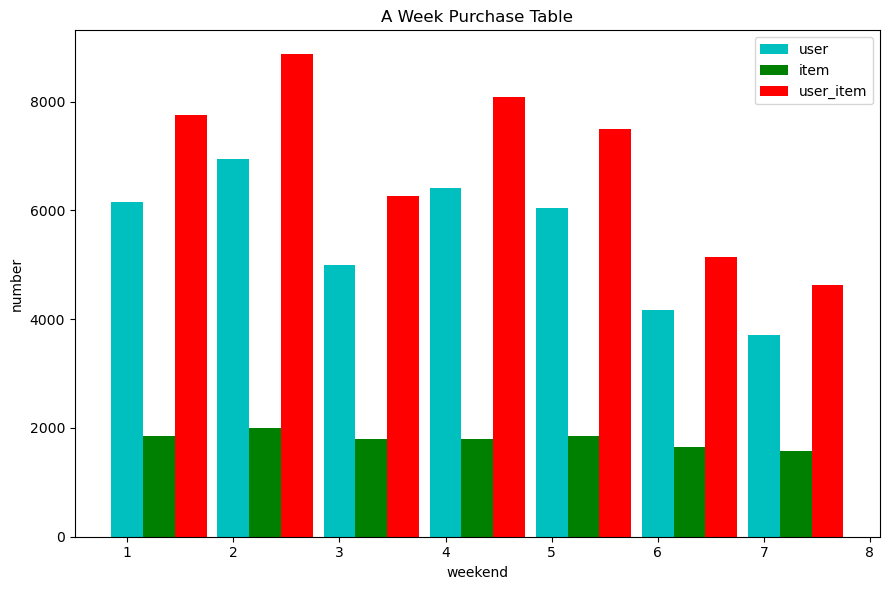

In [36]:
plt.figure(figsize=(9,6))#画布大小
width=0.3#条形宽度
plt.bar(df_re['weekend'],df_re['user_num'],width=width,color='c',label='user')
plt.bar(df_re['weekend']+width,df_re['item_num'],color='g',width=width,label='item')
plt.bar(df_re['weekend']+width*2,df_re['user_item_num'],color='r',width=width,label='user_item')
plt.xlabel('weekend')
plt.ylabel('number')
plt.title('A Week Purchase Table')
plt.tight_layout()
plt.legend()  # 显示图例（根据 label 参数自动生成）

## 结论

通过以上图表得出：周六周日商品购买数量、用户购买数量、购买记录个数普遍购买量少，  
主要原因可能是周末出去游玩、线下购物、与朋友聚餐、逛街等活动

# 月各天购买量

## 2016年2月

In [37]:
df_ac=get_from_action_data(fname=ACTION_201602_FILE)
# 将time字段转化为datetime类型并使用lambda函数将时间time转换为天
df_ac['time']=pd.to_datetime(df_ac['time']).apply(lambda x:x.day)
df_ac.head()

Iteration is stopped


,user_id,sku_id,time
351,269365,166345,1
649,235443,36692,1
980,247689,9112,1
1719,273959,102034,1
2153,226791,163550,1


In [38]:
df_ac['time'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29], dtype=int64)

In [ ]:
分组聚合数据汇总

In [39]:
# 每天购买用户去重数据
df_user=df_ac.groupby('time')['user_id'].nunique()
# 将df_user的Series数据类型转化为DataFrame类型
df_user=df_user.to_frame().reset_index()
df_user.columns=['day','user_num']
df_user

,day,user_num
0,1,454
1,2,383
2,3,302
3,4,256
4,5,160
5,6,120
6,7,82
7,8,100
8,9,113
9,10,121


In [41]:
# 每天购买商品数量去重数据
df_item=df_ac.groupby('time')['sku_id'].nunique()
# 将df_item的Series数据类型转化为DataFrame类型
df_item=df_item.to_frame().reset_index()
df_item.columns=['day','item_num']
df_item

,day,item_num
0,1,352
1,2,311
2,3,255
3,4,213
4,5,147
5,6,114
6,7,93
7,8,96
8,9,106
9,10,128


In [43]:
# 每天购买记录总数
df_ui=df_ac.groupby('time',as_index=False).size()
# 这里as_index为False后，time将不是索引列,他生成的是一个DataFram类型的数据，如果默认as_index为True，那生成的的一个Series数据，
# 即需要手动转换
df_ui.columns=['day','user_item_num']
df_ui

,day,user_item_num
0,1,539
1,2,462
2,3,357
3,4,297
4,5,179
5,6,134
6,7,107
7,8,109
8,9,127
9,10,150


In [ ]:
2月每天购买情况可视化

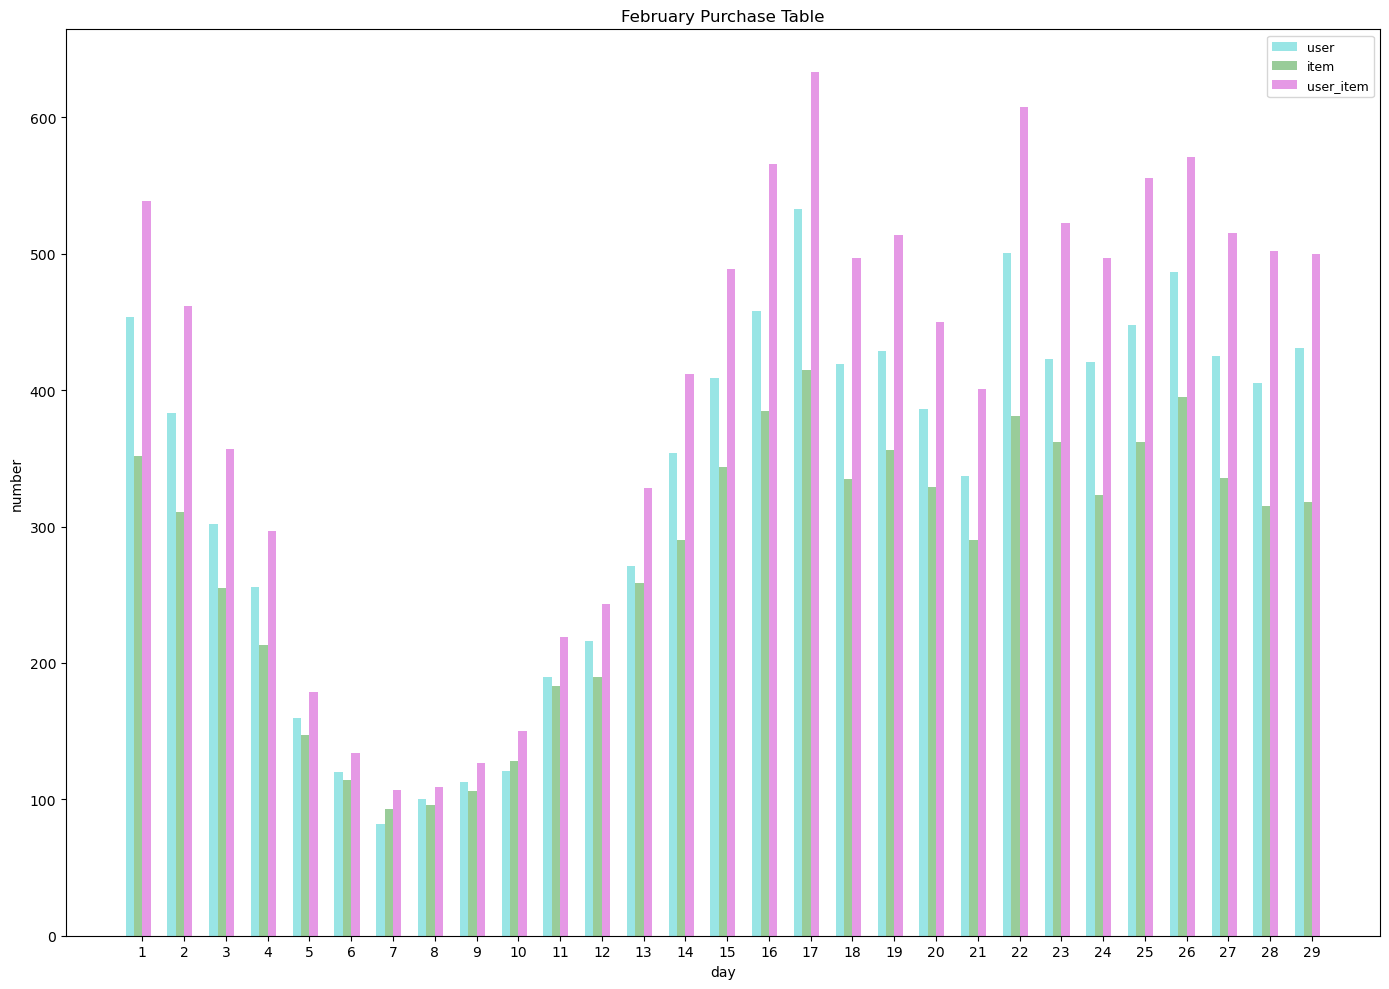

In [44]:
# 条形宽度
bar_width = 0.2
# 透明度
opacity = 0.4
# 天数
day_range = range(1,len(df_user['day']) + 1)
# 设置图片大小
plt.figure(figsize=(14,10))
plt.bar(df_user['day'], df_user['user_num'], bar_width, 
        alpha=opacity, color='c', label='user')
plt.bar(df_item['day']+bar_width, df_item['item_num'], 
        bar_width, alpha=opacity, color='g', label='item')
plt.bar(df_ui['day']+bar_width*2, df_ui['user_item_num'], 
        bar_width, alpha=opacity, color='m', label='user_item')

plt.xlabel('day')
plt.ylabel('number')
plt.title('February Purchase Table')
plt.xticks(df_user['day'] + bar_width * 3 / 2., day_range)
plt.tight_layout() 
plt.legend(prop={'size':9})

In [ ]:
分析：2月份5号到10号左右购买量非常少，原因是这几天是春节，许多快递都停业了，都在家过节所以销量极低

## 2016年3月

In [45]:
df_ac = get_from_action_data(fname=ACTION_201603_FILE)
# 将time字段转换为datetime类型并使用lambda匿名函数将时间time转换为天
df_ac['time'] = pd.to_datetime(df_ac['time']).apply(lambda x: x.day)
df_user = df_ac.groupby('time')['user_id'].nunique()
df_user = df_user.to_frame().reset_index()
df_user.columns = ['day', 'user_num']

df_item = df_ac.groupby('time')['sku_id'].nunique()
df_item = df_item.to_frame().reset_index()
df_item.columns = ['day', 'item_num']

df_ui = df_ac.groupby('time', as_index=False).size()
df_ui.columns = ['day', 'user_item_num']

Iteration is stopped


In [ ]:
3月销量情况可视化

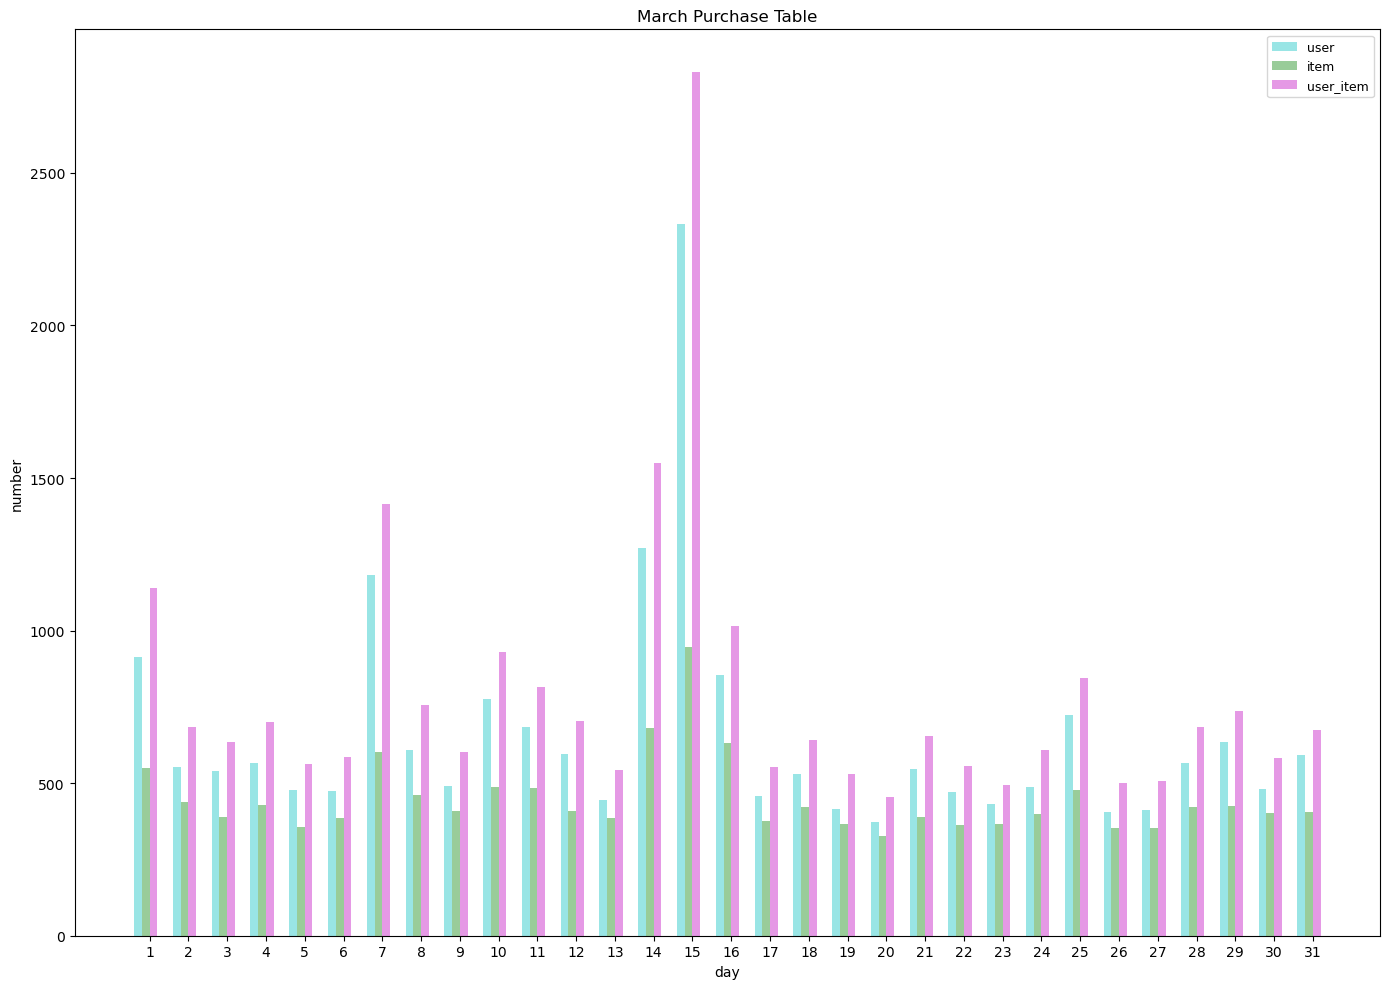

In [46]:
# 条形宽度
bar_width = 0.2
# 透明度
opacity = 0.4
# 天数
day_range = range(1,len(df_user['day']) + 1, 1)
# 设置图片大小
plt.figure(figsize=(14,10))
plt.bar(df_user['day'], df_user['user_num'], bar_width, 
        alpha=opacity, color='c', label='user')
plt.bar(df_item['day']+bar_width, df_item['item_num'], 
        bar_width, alpha=opacity, color='g', label='item')
plt.bar(df_ui['day']+bar_width*2, df_ui['user_item_num'], 
        bar_width, alpha=opacity, color='m', label='user_item')
plt.xlabel('day')
plt.ylabel('number')
plt.title('March Purchase Table')
plt.xticks(df_user['day'] + bar_width * 3 / 2., day_range)
plt.tight_layout() 
plt.legend(prop={'size':9})

In [ ]:
总体来看，3月份的记录高于2月份，月中购买量居多，原因可能是一些公司普遍月中发工资，有了资金就有了消费数量

## 2016年4月

In [47]:
df_ac = get_from_action_data(fname=ACTION_201604_FILE)

# 将time字段转换为datetime类型并使用lambda匿名函数将时间time转换为天
df_ac['time'] = pd.to_datetime(df_ac['time']).apply(lambda x: x.day)

df_user = df_ac.groupby('time')['user_id'].nunique()
df_user = df_user.to_frame().reset_index()
df_user.columns = ['day', 'user_num']

df_item = df_ac.groupby('time')['sku_id'].nunique()
df_item = df_item.to_frame().reset_index()
df_item.columns = ['day', 'item_num']

df_ui = df_ac.groupby('time', as_index=False).size()
df_ui.columns = ['day', 'user_item_num']

Iteration is stopped


In [48]:
# 4月份数据可视化

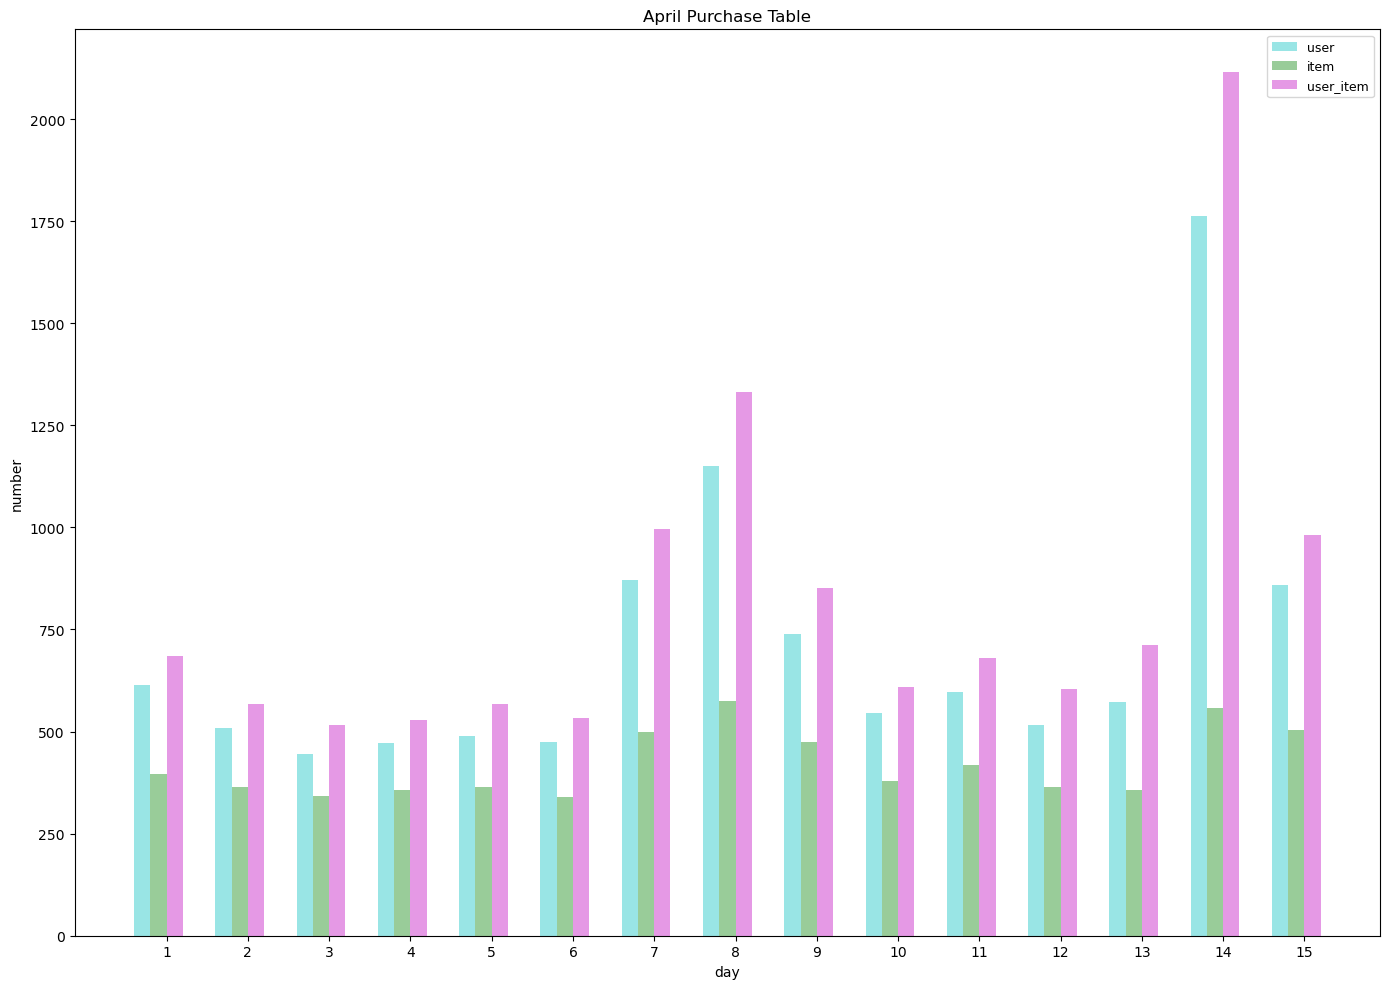

In [49]:
# 条形宽度
bar_width = 0.2
# 透明度
opacity = 0.4
# 天数
day_range = range(1,len(df_user['day']) + 1, 1)
# 设置图片大小
plt.figure(figsize=(14,10))

plt.bar(df_user['day'], df_user['user_num'], bar_width, 
        alpha=opacity, color='c', label='user')
plt.bar(df_item['day']+bar_width, df_item['item_num'], 
        bar_width, alpha=opacity, color='g', label='item')
plt.bar(df_ui['day']+bar_width*2, df_ui['user_item_num'], 
        bar_width, alpha=opacity, color='m', label='user_item')

plt.xlabel('day')
plt.ylabel('number')
plt.title('April Purchase Table')
plt.xticks(df_user['day'] + bar_width * 3 / 2., day_range)

plt.tight_layout() 
plt.legend(prop={'size':9})

In [ ]:
分析：每个月中旬都有较强的购物欲望，适合促销！或者说，很多月在月中发工资了

# 周每天商品类别销售情况

## 定义函数提取行为记录中商品类别数据

In [50]:
# 从行为记录中提取商品类别数据
def get_from_action_data(fname, chunk_size=50000):
    reader = pd.read_csv(fname, header=0, iterator=True)
    chunks = []
    loop = True
    while loop:
        try:
            chunk = reader.get_chunk(chunk_size)[
                ["cate", "brand", "type", "time"]]
            chunks.append(chunk)
        except StopIteration:
            loop = False
            print("Iteration is stopped")

    df_ac = pd.concat(chunks, ignore_index=True)
    # type=4,为购买
    df_ac = df_ac[df_ac['type'] == 4]

    return df_ac[["cate", "brand", "type", "time"]]

## 提取全部商品类别数据

In [51]:
df_ac = []
df_ac.append(get_from_action_data(fname=ACTION_201602_FILE))
df_ac.append(get_from_action_data(fname=ACTION_201603_FILE))
df_ac.append(get_from_action_data(fname=ACTION_201604_FILE))
df_ac = pd.concat(df_ac, ignore_index=True)
# 将time字段转换为datetime类型
df_ac['time'] = pd.to_datetime(df_ac['time'])
# 使用lambda匿名函数将时间time转换为星期(周一为1, 周日为７)
df_ac['time'] = df_ac['time'].apply(lambda x: x.weekday() + 1)
# 观察有几个类别商品
df_ac.groupby(df_ac['cate']).count()

Iteration is stopped
Iteration is stopped
Iteration is stopped


,brand,type,time
cate,,,
4,9326,9326,9326
5,8138,8138,8138
6,6982,6982,6982
7,6214,6214,6214
8,13281,13281,13281
9,4104,4104,4104
10,189,189,189
11,18,18,18


## 商品不同类别销量可视化

In [52]:
# 查看自己电脑上的字体
from matplotlib.font_manager import FontManager
fm=FontManager()
[font.name for font in fm.ttflist]

['STIXNonUnicode',
 'DejaVu Serif',
 'DejaVu Serif',
 'cmb10',
 'STIXGeneral',
 'DejaVu Serif Display',
 'DejaVu Sans',
 'cmr10',
 'DejaVu Sans',
 'cmtt10',
 'STIXGeneral',
 'STIXSizeThreeSym',
 'cmsy10',
 'STIXSizeTwoSym',
 'STIXNonUnicode',
 'STIXNonUnicode',
 'DejaVu Sans Mono',
 'cmss10',
 'STIXNonUnicode',
 'DejaVu Sans Mono',
 'STIXSizeFourSym',
 'DejaVu Serif',
 'STIXSizeThreeSym',
 'STIXSizeTwoSym',
 'STIXGeneral',
 'STIXGeneral',
 'DejaVu Sans',
 'DejaVu Sans',
 'DejaVu Serif',
 'DejaVu Sans Mono',
 'cmex10',
 'cmmi10',
 'STIXSizeFourSym',
 'STIXSizeFiveSym',
 'DejaVu Sans Display',
 'STIXSizeOneSym',
 'STIXSizeOneSym',
 'DejaVu Sans Mono',
 'Trebuchet MS',
 'Malgun Gothic',
 'Bookman Old Style',
 'Microsoft Himalaya',
 'Blackadder ITC',
 'Arial',
 'Arial',
 'Trebuchet MS',
 'Rockwell',
 'Felix Titling',
 'Tahoma',
 'Perpetua',
 'FZCuHeiSongS-B-GB',
 'Lucida Fax',
 'Segoe UI',
 'Bodoni MT',
 'YouYuan',
 'Corbel',
 'Trebuchet MS',
 'Myanmar Text',
 'Bookshelf Symbol 7',
 'Comic

,cate,brand,type,time
0,9,306,4,1
1,4,174,4,1
2,5,78,4,1
3,5,78,4,1
4,4,306,4,1


time  cate
1     4       1466
      5       1417
      6       1162
      7       1089
      8       1892
Name: brand, dtype: int64

Text(0.5, 1.0, '不同商品周销量表')

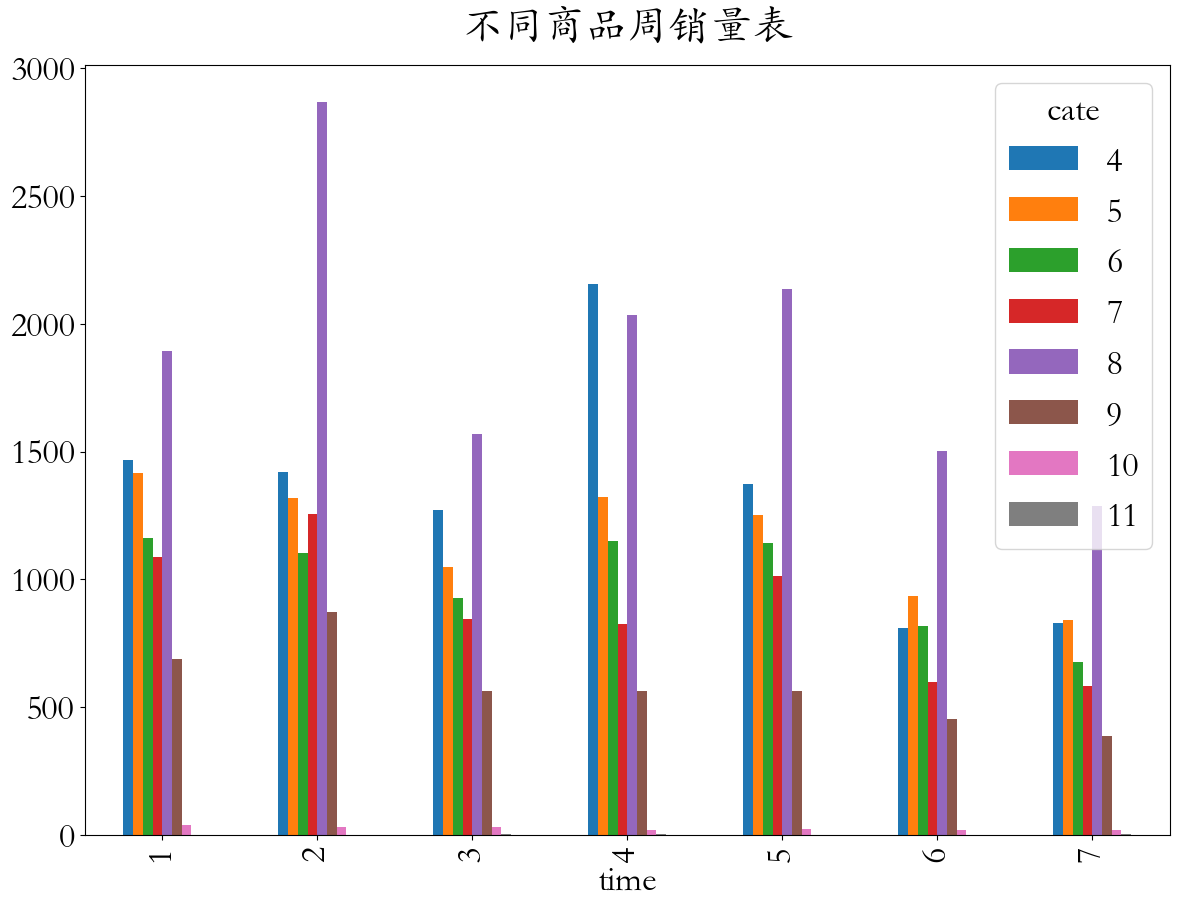

In [53]:
# 周一到周日每天购买商品类别数量统计
plt.rcParams['font.family'] = 'STKaiti'
plt.rcParams['font.size'] = 25
# 查看源数据
display(df_ac.head())
df_product=df_ac['brand'].groupby([df_ac['time'],df_ac['cate']]).count()
display(df_product.head())
df_product=df_product.unstack()#将行索引变为列索引
df_product.plot(kind='bar',figsize=(14,10))
plt.title(label='不同商品周销量表',pad = 20)

# 每月各类商品销售情况(只关注商品8)

## 加载全部数据

In [54]:
df_ac2 = get_from_action_data(fname=ACTION_201602_FILE)
# 将time字段转换为datetime类型并使用lambda匿名函数将时间time转换为天
df_ac2['time'] = pd.to_datetime(df_ac2['time']).apply(lambda x: x.day)

df_ac3 = get_from_action_data(fname=ACTION_201603_FILE)
# 将time字段转换为datetime类型并使用lambda匿名函数将时间time转换为天
df_ac3['time'] = pd.to_datetime(df_ac3['time']).apply(lambda x: x.day)

df_ac4 = get_from_action_data(fname=ACTION_201604_FILE)
# 将time字段转换为datetime类型并使用lambda匿名函数将时间time转换为天
df_ac4['time'] = pd.to_datetime(df_ac4['time']).apply(lambda x: x.day)

Iteration is stopped
Iteration is stopped
Iteration is stopped


## 商品8每月销售数据按天分组聚合统计销量

In [56]:
dc_cate2 = df_ac2[df_ac2['cate']==8]#筛选出类别8
# 类别8下面的子类，大类下面，不同品牌
#是一个Series数据
dc_cate2 = dc_cate2['brand'].groupby(dc_cate2['time']).count()
display(dc_cate2.head())
dc_cate2 = dc_cate2.to_frame().reset_index()
display(dc_cate2.head())
dc_cate2.columns = ['day', 'product_num']

dc_cate3 = df_ac3[df_ac3['cate']==8]
dc_cate3 = dc_cate3['brand'].groupby(dc_cate3['time']).count()
dc_cate3 = dc_cate3.to_frame().reset_index()
dc_cate3.columns = ['day', 'product_num']

dc_cate4 = df_ac4[df_ac4['cate']==8]
dc_cate4 = dc_cate4['brand'].groupby(dc_cate4['time']).count()
dc_cate4 = dc_cate4.to_frame().reset_index()
dc_cate4.columns = ['day', 'product_num']

time
1    90
2    84
3    78
4    47
5    26
Name: brand, dtype: int64

,time,brand
0,1,90
1,2,84
2,3,78
3,4,47
4,5,26


## 商品8按天统计销量可视化

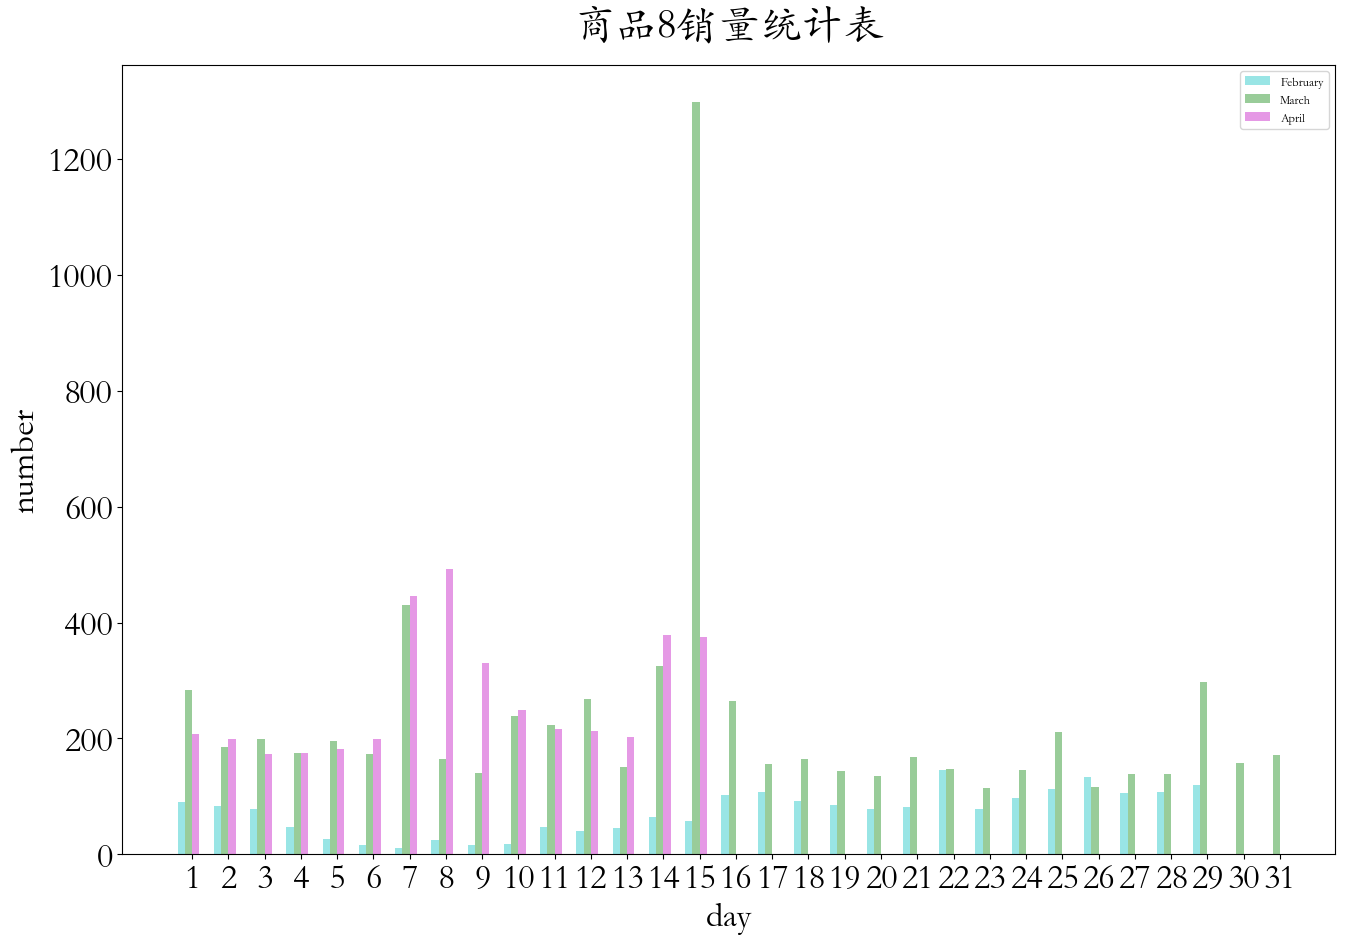

In [57]:
# 条形宽度
bar_width = 0.2
# 透明度
opacity = 0.4
# 天数
day_range = range(1,len(dc_cate3['day']) + 1, 1)
plt.rcParams['font.family'] = 'STKaiti'
plt.rcParams['font.size'] = 25
# 设置图片大小
plt.figure(figsize=(14,10))

plt.bar(dc_cate2['day'], dc_cate2['product_num'], bar_width, 
        alpha=opacity, color='c', label='February')
plt.bar(dc_cate3['day']+bar_width, dc_cate3['product_num'], 
        bar_width, alpha=opacity, color='g', label='March')
plt.bar(dc_cate4['day']+bar_width*2, dc_cate4['product_num'], 
        bar_width, alpha=opacity, color='m', label='April')

plt.xlabel('day')
plt.ylabel('number')
plt.title('商品8销量统计表',pad = 20)
plt.xticks(dc_cate3['day'] + bar_width * 3 / 2., day_range)
plt.tight_layout() 
plt.legend(prop={'size':9})

In [ ]:
分析：2月份对类别8商品的购买普遍偏低，3，4月份普遍偏高，3月15日购买极其多！ 
同时发现，3,4月份类别8销售记录在前半个月特别相似，除了4月8号，9号和3月15号。

# 查看特定用户对特定商品的轨迹

## 定义函数筛选用户--商品数据

In [58]:
def spec_ui_action_data(fname, user_id, sku_id, chunk_size=100000):
    reader = pd.read_csv(fname, header=0, iterator=True)
    chunks = []
    loop = True
    while loop:
        try:
            chunk = reader.get_chunk(chunk_size)[
                ["user_id", "sku_id", "type", "time"]]
            chunks.append(chunk)
        except StopIteration:
            loop = False
            print("Iteration is stopped")

    df_ac = pd.concat(chunks, ignore_index=True)
    df_ac = df_ac[(df_ac['user_id'] == user_id) & (df_ac['sku_id'] == sku_id)]

    return df_ac

## 筛选全部数据

In [59]:
def explore_user_item_via_time():
    user_id = 266079
    sku_id = 138778
    df_ac = []
    df_ac.append(spec_ui_action_data(ACTION_201602_FILE, user_id, sku_id))
    df_ac.append(spec_ui_action_data(ACTION_201603_FILE, user_id, sku_id))
    df_ac.append(spec_ui_action_data(ACTION_201604_FILE, user_id, sku_id))
    df_ac = pd.concat(df_ac, ignore_index=False)
    print(df_ac.sort_values(by='time'))

## 进行用户和商品数据筛选

In [60]:
explore_user_item_via_time()

Iteration is stopped
Iteration is stopped
Iteration is stopped
    user_id  sku_id  type                 time
0    266079  138778     1  2016-01-31 23:59:02
1    266079  138778     6  2016-01-31 23:59:03
15   266079  138778     6  2016-01-31 23:59:40


# 特征工程

从以下几个维度进行展开

## 特征工程前的总体概览

### 用户基本特征

获取基本的用户特征，基于用户本身属性多为类别特征的特点，对age,sex,usr_lv_cd进行独热编码操作，对于用户注册时间暂时不处理

### 商品基本特征

根据商品文件获取基本的特征  
针对属性a1,a2,a3进行独热编码  
商品类别和品牌直接作为特征

### 评论特征

分时间段  
对评论数进行独热编码

### 行为特征

分时间段  
对行为类别进行独热编码  
分别按照用户-类别行为分组和用户-类别-商品行为分组统计，然后计算  
用户对同类别下其他商品的行为计数  
不同时间累积的行为计数（3,5,7,10,15,21,30）

### 累计用户特征

分时间段  
用户不同行为的  
购买转化率  
均值

### 用户近期行为特征

在上面针对用户进行累积特征提取的基础上，分别提取用户近一个月、近三天的特征，然后提取一个月内用户除去最近三天的行为占据一个月的行为的比重

### 用户对同类别下各种商品的行为

用户对各个类别的各项行为操作统计  
用户对各个类别操作行为统计占对所有类别操作行为统计的比重

### 累计商品特征

分时间段  
针对商品的不同行为的  
购买转化率  
均值

### 类别特征

分时间段下各个商品类别的  
购买转化率  
均值

## 数据加载

导包

In [72]:
from datetime import datetime
from datetime import timedelta
import pandas as pd
import numpy as np
import gc

In [73]:
action_1_path= r"D:\allsoft\模块数据\京东实战数据\JData_Action_201602.csv"
action_2_path= r"D:\allsoft\模块数据\京东实战数据\JData_Action_201603.csv"
action_3_path= r"D:\allsoft\模块数据\京东实战数据\JData_Action_201604.csv"
comment_path = r"D:\allsoft\模块数据\京东实战数据\JData_Comment.csv"
product_path= r"D:\allsoft\模块数据\京东实战数据\JData_Product.csv"
user_path= r"D:\allsoft\模块数据\京东实战数据\JData_User.csv"

定义函数提取数据并转换

In [74]:
def get_actions_1():
    action = pd.read_csv(action_1_path)
    action[['user_id','sku_id','model_id','type','cate','brand']] = \
    action[['user_id','sku_id','model_id','type','cate','brand']].astype('float32')
    return action
def get_actions_2():
    action = pd.read_csv(action_2_path)
    action[['user_id','sku_id','model_id','type','cate','brand']] = \
    action[['user_id','sku_id','model_id','type','cate','brand']].astype('float32')
    return action
def get_actions_3():
    action = pd.read_csv(action_3_path)
    action[['user_id','sku_id','model_id','type','cate','brand']] = \
    action[['user_id','sku_id','model_id','type','cate','brand']].astype('float32')
    return action

# 读取并拼接所有行为记录文件
def get_all_action():
    action_1 = get_actions_1()
    action_2 = get_actions_2()
    action_3 = get_actions_3()
    actions = pd.concat([action_1, action_2, action_3]) # type: pd.DataFrame
    return actions

# 获取某个时间段的行为记录
def get_actions(start_date, end_date, all_actions):
    """
    :param start_date:开始日期
    :param end_date:结束日期
    :return: actions: 返回数据
    """
    actions = all_actions[(all_actions.time >= start_date) & (all_actions.time < end_date)].copy()
    return actions

## 用户特征

### 用户基本特征

获取基本的用户特征，基于用户本身属性多为类别特征的特点，对age,sex,usr_lv_cd进行独热编码操作，对于用户注册时间暂时不处理

In [77]:
from sklearn import preprocessing
def get_basic_user_feat():
    # 针对年龄的中文字符的问题处理，首先是读入的时候编码，填充空值，然后将其数值化，最后独热编码，此外对于sex也进行了数值类型转换
    user=pd.read_csv(user_path)
    user.dropna(axis=0,how='any',inplace=True)
    user['sex']=user['sex'].astype(int)
    user['age']=user['age'].astype(int)
    le=preprocessing.LabelEncoder()
    age_df=le.fit_transform(user['age'])

    age_df=pd.get_dummies(age_df,prefix='age',dtype=int)#多列
    sex_df=pd.get_dummies(user['sex'],prefix='sex',dtype=int)
    user_lv_df=pd.get_dummies(user['user_lv_cd'],prefix='user_lv_cd',dtype=int)
    user=pd.concat([user['user_id'],age_df,sex_df,user_lv_df],axis=1)
    return user

In [78]:
user=get_basic_user_feat()
display(user.head(),user.shape)
del user
gc.collect()

,user_id,age_0,age_1,age_2,age_3,age_4,age_5,age_6,sex_0,sex_1,sex_2,user_lv_cd_1,user_lv_cd_2,user_lv_cd_3,user_lv_cd_4,user_lv_cd_5
0,200001.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,200002.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,200003.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,200004.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,200005.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


(105321, 16)

1191

## 商品特征

### 商品基本特征

根据商品文件获取基本的特征，针对属性a1,a2,a3进行独热编码,商品类型和品牌直接作为特征

In [84]:
def get_basic_product_feat():
    product = pd.read_csv(product_path)
    attr1_df = pd.get_dummies(product["a1"], prefix="a1",dtype=int)
    attr2_df = pd.get_dummies(product["a2"], prefix="a2",dtype=int)
    attr3_df = pd.get_dummies(product["a3"], prefix="a3",dtype=int)
    product = pd.concat([product[['sku_id', 'cate', 'brand']], attr1_df, attr2_df, attr3_df], axis=1)
    return product

In [80]:
df1=pd.DataFrame({'A':[1,2,3],})
df1

,A
0,1
1,2
2,3


In [83]:
pd.get_dummies(df1['A'],prefix='cross',dtype=int)

,cross_1,cross_2,cross_3
0,1,0,0
1,0,1,0
2,0,0,1


## 评论特征

对于评论特征进行转换：分时间段  
对评论数进行独热编码

In [85]:
def get_comments_product_feat(end_date):
    comments = pd.read_csv(comment_path)
    comments = comments[comments.dt <= end_date]# 某日期之前的评论数据
    df = pd.get_dummies(comments['comment_num'], prefix='comment_num',dtype=int)
    # 为了防止某个时间段不具备评论数为0的情况（测试集出现过这种情况）
    for i in range(0, 5):
        if 'comment_num_' + str(i) not in df.columns:
            df['comment_num_' + str(i)] = 0
    df = df[['comment_num_0', 'comment_num_1', 'comment_num_2', 
             'comment_num_3', 'comment_num_4']]
    
    comments = pd.concat([comments, df], axis=1) # type: pd.DataFrame

    comments = comments[['sku_id', 'has_bad_comment', 'bad_comment_rate',
                         'comment_num_0', 'comment_num_1','comment_num_2', 
                         'comment_num_3', 'comment_num_4']]
    return comments

In [92]:
start_date='2016-02-01'
end_date=datetime.strptime(start_date,'%Y-%m-%d')+timedelta(days=3)
end_date=end_date.strftime('%Y-%m-%d')
display(start_date,type(start_date))
comments=get_comments_product_feat(end_date)#字符串
display(comments.head(),comments.shape)
del comments
gc.collect()


'2016-02-01'

str

,sku_id,has_bad_comment,bad_comment_rate,comment_num_0,comment_num_1,comment_num_2,comment_num_3,comment_num_4
0,1000,1,0.0417,0,0,0,1,0
1,10000,0,0.0000,0,0,1,0,0
2,100011,1,0.0376,0,0,0,0,1
3,100018,0,0.0000,0,0,0,1,0
4,100020,0,0.0000,0,0,0,1,0


(46546, 8)

11226

## 行为特征

### 用户-类别-商品计数统计

分时间段  
对行为类别进行独热编码  
分别按照用户-类别行为分组和用户-类别-商品行为分组统计，然后计算  
用户对同类别下其他商品的行为计数  
针对用户对同类别下目标商品的行为计数与该时间段的行为均值作差

### 函数定义(用户-类别-商品计数)

In [93]:
def get_action_feat(start_date, end_date, all_actions, day):
    actions = get_actions(start_date, end_date, all_actions)
    actions = actions[['user_id', 'sku_id', 'cate','type']]
    # 对行为类别进行独热编码
    prefix = 'type_action_duration_%s_days' % day
    df = pd.get_dummies(actions['type'], prefix=prefix)
    actions = pd.concat([actions, df], axis=1)
    
    # 分组统计，用户-类别-商品,不同用户对不同类别下商品的行为计数
    actions = actions.groupby(['user_id', 'cate','sku_id'], as_index=False).sum()
    # 分组统计，用户-类别，不同用户对不同商品类别的行为计数
    user_cate = actions.groupby(['user_id','cate'], as_index=False).sum()
    del user_cate['sku_id']
    del user_cate['type']
    # 数据合并
    actions = pd.merge(actions, user_cate, how='left', on=['user_id','cate'])
    
    # 前述两种分组含有相同名称的不同行为的计数，系统会自动针对名称调整添加后缀,x,y
    # 所以这里作差统计的是同一类别下其他商品的行为计数
    # 不同时间累积的行为计数（3,5,7,10,15,21,30）表示时间间隔天数
    # 求出不同用户不同类别对其他商品的行为计数
    actions[prefix+'_1_others'] = actions[prefix+'_1.0_y'] - actions[prefix+'_1.0_x']
    actions[prefix+'_2_others'] = actions[prefix+'_2.0_y'] - actions[prefix+'_2.0_x']
    actions[prefix+'_3_others'] = actions[prefix+'_3.0_y'] - actions[prefix+'_3.0_x']
    actions[prefix+'_4_others'] = actions[prefix+'_4.0_y'] - actions[prefix+'_4.0_x']
    actions[prefix+'_5_others'] = actions[prefix+'_5.0_y'] - actions[prefix+'_5.0_x']
    actions[prefix+'_6_others'] = actions[prefix+'_6.0_y'] - actions[prefix+'_6.0_x']
    
    
    # 统计用户对不同类别下商品计数与该类别下商品行为计数均值（对时间）的差值
    # 如果大于是正数表示在该时间段内活跃
    actions[prefix+'minus_mean_1'] = actions[prefix+'_1.0_x'] - (actions[prefix+'_1.0_x']/day)
    actions[prefix+'minus_mean_2'] = actions[prefix+'_2.0_x'] - (actions[prefix+'_2.0_x']/day)
    actions[prefix+'minus_mean_3'] = actions[prefix+'_3.0_x'] - (actions[prefix+'_3.0_x']/day)
    actions[prefix+'minus_mean_4'] = actions[prefix+'_4.0_x'] - (actions[prefix+'_4.0_x']/day)
    actions[prefix+'minus_mean_5'] = actions[prefix+'_5.0_x'] - (actions[prefix+'_5.0_x']/day)
    actions[prefix+'minus_mean_6'] = actions[prefix+'_6.0_x'] - (actions[prefix+'_6.0_x']/day)
    del actions['type']
    return actions

代码解读

In [94]:
all_actions = get_all_action()
start_date = '2016-02-01'
end_date = datetime.strptime(start_date, '%Y-%m-%d') + timedelta(days=3)
end_date = end_date.strftime('%Y-%m-%d')
# 获取一定时间段内数据
actions = get_actions(start_date, end_date, all_actions)
display(actions.head(),actions.shape)
del all_actions
gc.collect()

,user_id,sku_id,time,model_id,type,cate,brand
29,272629.0,107774.0,2016-02-01 00:00:00,NaN,1.0,10.0,36.0
30,272629.0,107774.0,2016-02-01 00:00:00,NaN,1.0,10.0,36.0
31,272629.0,107774.0,2016-02-01 00:00:00,0.0,6.0,10.0,36.0
32,272629.0,107774.0,2016-02-01 00:00:00,NaN,1.0,10.0,36.0
33,272629.0,107774.0,2016-02-01 00:00:00,216.0,6.0,10.0,36.0


(1005110, 7)

0

In [95]:
# 提取部分特征
actions = actions[['user_id', 'sku_id', 'cate','type']]
display(actions.head())
# 对行为类别进行独热编码
# 这里的3表示3天的时间间隔
df = pd.get_dummies(actions['type'], prefix='type_action_duration_%s_days'%3,dtype=int)
display(df.head())

,user_id,sku_id,cate,type
29,272629.0,107774.0,10.0,1.0
30,272629.0,107774.0,10.0,1.0
31,272629.0,107774.0,10.0,6.0
32,272629.0,107774.0,10.0,1.0
33,272629.0,107774.0,10.0,6.0


,type_action_duration_3_days_1.0,type_action_duration_3_days_2.0,type_action_duration_3_days_3.0,type_action_duration_3_days_4.0,type_action_duration_3_days_5.0,type_action_duration_3_days_6.0
29,1,0,0,0,0,0
30,1,0,0,0,0,0
31,0,0,0,0,0,1
32,1,0,0,0,0,0
33,0,0,0,0,0,1


In [96]:
# 数据合并
actions = pd.concat([actions, df], axis=1)  # type: pd.DataFrame
display(actions.head(),actions.shape)
del df
# 删除 type 这一列
del actions['type']
gc.collect()

,user_id,sku_id,cate,type,type_action_duration_3_days_1.0,type_action_duration_3_days_2.0,type_action_duration_3_days_3.0,type_action_duration_3_days_4.0,type_action_duration_3_days_5.0,type_action_duration_3_days_6.0
29,272629.0,107774.0,10.0,1.0,1,0,0,0,0,0
30,272629.0,107774.0,10.0,1.0,1,0,0,0,0,0
31,272629.0,107774.0,10.0,6.0,0,0,0,0,0,1
32,272629.0,107774.0,10.0,1.0,1,0,0,0,0,0
33,272629.0,107774.0,10.0,6.0,0,0,0,0,0,1


(1005110, 10)

482

In [97]:
# 分组统计，用户-类别-商品，不同用户对不同类别下商品的行为计数
# 统计的行为计数是3天内时间段行为的总数
actions=actions.groupby(['user_id','cate','sku_id']
                       ,as_index=False).sum()
display(actions.head(),actions.shape)

,user_id,cate,sku_id,type_action_duration_3_days_1.0,type_action_duration_3_days_2.0,type_action_duration_3_days_3.0,type_action_duration_3_days_4.0,type_action_duration_3_days_5.0,type_action_duration_3_days_6.0
0,200002.0,4.0,7199.0,2,0,0,0,0,0
1,200002.0,4.0,28973.0,4,0,0,0,0,6
2,200002.0,4.0,73364.0,6,0,0,0,0,3
3,200002.0,4.0,118303.0,2,0,0,0,0,6
4,200002.0,4.0,149851.0,2,0,0,0,0,5


(119134, 9)

In [99]:
# 分组统计，用户-类别，不同用户对不同类别下的行为计数
# 统计的是大类，上面统计的是大类下的小类
# 比如上面统计的是洗发水类别下的小类：海飞丝，潘婷等小类数据
# 这里统计的是洗发水总数据
user_cate=actions.groupby(['user_id','cate'],as_index=False).sum()
del user_cate['sku_id']
display(user_cate.head(),user_cate.shape)

,user_id,cate,type_action_duration_3_days_1.0,type_action_duration_3_days_2.0,type_action_duration_3_days_3.0,type_action_duration_3_days_4.0,type_action_duration_3_days_5.0,type_action_duration_3_days_6.0
0,200002.0,4.0,16,0,0,0,0,20
1,200002.0,5.0,4,0,0,0,0,6
2,200002.0,7.0,4,0,0,0,0,3
3,200002.0,8.0,4,0,0,0,0,12
4,200003.0,4.0,8,0,0,0,0,12


(35577, 8)

In [101]:
# 和原始数据集合并
actions=pd.merge(actions,user_cate,how='left',on=['user_id','cate'])
del user_cate
gc.collect()
display(actions.head(),actions.shape)

,user_id,cate,sku_id,type_action_duration_3_days_1.0_x,type_action_duration_3_days_2.0_x,type_action_duration_3_days_3.0_x,type_action_duration_3_days_4.0_x,type_action_duration_3_days_5.0_x,type_action_duration_3_days_6.0_x,type_action_duration_3_days_1.0_y,type_action_duration_3_days_2.0_y,type_action_duration_3_days_3.0_y,type_action_duration_3_days_4.0_y,type_action_duration_3_days_5.0_y,type_action_duration_3_days_6.0_y
0,200002.0,4.0,7199.0,2,0,0,0,0,0,16,0,0,0,0,20
1,200002.0,4.0,28973.0,4,0,0,0,0,6,16,0,0,0,0,20
2,200002.0,4.0,73364.0,6,0,0,0,0,3,16,0,0,0,0,20
3,200002.0,4.0,118303.0,2,0,0,0,0,6,16,0,0,0,0,20
4,200002.0,4.0,149851.0,2,0,0,0,0,5,16,0,0,0,0,20


(119134, 15)

用户对同一类别下其他商品的行为计数

In [102]:
prefix = 'type_action_duration_%s_days' % 3
# 用户对同类别下，其他商品的点击行为计数
# 统计，当前特定商品的行为和其他同类商品（竞品）的行为数据对比
# 比如，洗发水类别下，有不同的商品：海飞丝、飘柔、力士……
actions[prefix+'_1_others'] = actions[prefix+'_1.0_y'] - actions[prefix+'_1.0_x']·
display(actions.head(),actions.shape)
del actions
gc.collect()

,user_id,cate,sku_id,type_action_duration_3_days_1.0_x,type_action_duration_3_days_2.0_x,type_action_duration_3_days_3.0_x,type_action_duration_3_days_4.0_x,type_action_duration_3_days_5.0_x,type_action_duration_3_days_6.0_x,type_action_duration_3_days_1.0_y,type_action_duration_3_days_2.0_y,type_action_duration_3_days_3.0_y,type_action_duration_3_days_4.0_y,type_action_duration_3_days_5.0_y,type_action_duration_3_days_6.0_y,type_action_duration_3_days_1_others
0,200002.0,4.0,7199.0,2,0,0,0,0,0,16,0,0,0,0,20,14
1,200002.0,4.0,28973.0,4,0,0,0,0,6,16,0,0,0,0,20,12
2,200002.0,4.0,73364.0,6,0,0,0,0,3,16,0,0,0,0,20,10
3,200002.0,4.0,118303.0,2,0,0,0,0,6,16,0,0,0,0,20,14
4,200002.0,4.0,149851.0,2,0,0,0,0,5,16,0,0,0,0,20,14


(119134, 16)

0

## 用户-行为

累计用户特征

In [103]:
#函数定义
def get_accumulate_user_feat(end_date, all_actions, day):
    start_date = datetime.strptime(end_date, '%Y-%m-%d') - timedelta(days=day)
    start_date = start_date.strftime('%Y-%m-%d')
    prefix = 'user_action_duration_%s_days' % day

    actions = get_actions(start_date, end_date, all_actions)
    df = pd.get_dummies(actions['type'], prefix=prefix,dtype=int) # 独热编码

    actions = pd.concat([actions[['user_id']], df], axis=1)
    del df
    gc.collect()
    # 分组统计，按用户分组，统计用户各项行为的转化率、均值
    actions = actions.groupby(['user_id'], as_index=False).sum()
    actions[prefix + '_1_ratio'] =  np.log(1 + actions[prefix + '_4.0']) - np.log(1 + actions[prefix +'_1.0'])
    actions[prefix + '_2_ratio'] =  np.log(1 + actions[prefix + '_4.0']) - np.log(1 + actions[prefix +'_2.0'])
    actions[prefix + '_3_ratio'] =  np.log(1 + actions[prefix + '_4.0']) - np.log(1 + actions[prefix +'_3.0'])
    actions[prefix + '_5_ratio'] =  np.log(1 + actions[prefix + '_4.0']) - np.log(1 + actions[prefix +'_5.0'])
    actions[prefix + '_6_ratio'] =  np.log(1 + actions[prefix + '_4.0']) - np.log(1 + actions[prefix +'_6.0'])
    # 均值
    actions[prefix + '_1_mean'] = actions[prefix + '_1.0'] / day
    actions[prefix + '_2_mean'] = actions[prefix + '_2.0'] / day
    actions[prefix + '_3_mean'] = actions[prefix + '_3.0'] / day
    actions[prefix + '_4_mean'] = actions[prefix + '_4.0'] / day
    actions[prefix + '_5_mean'] = actions[prefix + '_5.0'] / day
    actions[prefix + '_6_mean'] = actions[prefix + '_6.0'] / day
    return actions

代码解读

In [104]:
# 加载一定时间段内所有数据
prefix = 'user_action_duration_%s_days' % 3
all_actions = get_all_action()
start_date = '2016-02-01'
end_date = datetime.strptime(start_date, '%Y-%m-%d') + timedelta(days=3)
end_date = end_date.strftime('%Y-%m-%d')
# 获取一定时间段内数据
actions = get_actions(start_date, end_date, all_actions)
display(actions.head(),actions.shape)
del all_actions
gc.collect()

,user_id,sku_id,time,model_id,type,cate,brand
29,272629.0,107774.0,2016-02-01 00:00:00,NaN,1.0,10.0,36.0
30,272629.0,107774.0,2016-02-01 00:00:00,NaN,1.0,10.0,36.0
31,272629.0,107774.0,2016-02-01 00:00:00,0.0,6.0,10.0,36.0
32,272629.0,107774.0,2016-02-01 00:00:00,NaN,1.0,10.0,36.0
33,272629.0,107774.0,2016-02-01 00:00:00,216.0,6.0,10.0,36.0


(1005110, 7)

469

用户行为统计计数

In [109]:
df=pd.get_dummies(actions['type'],prefix=prefix)
display(df.head(),df.shape)
actions=pd.concat([actions[['user_id']],df],axis=1)
actions=actions.groupby('user_id',as_index=False).sum()
display(actions.head(),actions.shape)

,user_action_duration_3_days_1.0,user_action_duration_3_days_2.0,user_action_duration_3_days_3.0,user_action_duration_3_days_4.0,user_action_duration_3_days_5.0,user_action_duration_3_days_6.0
29,True,False,False,False,False,False
30,True,False,False,False,False,False
31,False,False,False,False,False,True
32,True,False,False,False,False,False
33,False,False,False,False,False,True


(1005110, 6)

,user_id,user_action_duration_3_days_1.0,user_action_duration_3_days_2.0,user_action_duration_3_days_3.0,user_action_duration_3_days_4.0,user_action_duration_3_days_5.0,user_action_duration_3_days_6.0
0,200002.0,28,0,0,0,0,41
1,200003.0,20,0,0,0,0,31
2,200008.0,8,0,0,0,0,20
3,200023.0,1,0,0,0,0,0
4,200030.0,8,0,0,0,0,17


(22210, 7)

In [112]:
# 不同行为转化率和均值
actions[prefix + '_1_ratio'] =  np.log(1 + actions[prefix + '_4.0']) - np.log(1 + actions[prefix +'_1.0'])
actions[prefix + '_1_mean'] = actions[prefix + '_1.0'] / 3
actions.head(10)

,user_id,user_action_duration_3_days_1.0,user_action_duration_3_days_2.0,user_action_duration_3_days_3.0,user_action_duration_3_days_4.0,user_action_duration_3_days_5.0,user_action_duration_3_days_6.0,user_action_duration_3_days_1_ratio,user_action_duration_3_days_1_mean
0,200002.0,28,0,0,0,0,41,-3.367296,9.333333
1,200003.0,20,0,0,0,0,31,-3.044522,6.666667
2,200008.0,8,0,0,0,0,20,-2.197225,2.666667
3,200023.0,1,0,0,0,0,0,-0.693147,0.333333
4,200030.0,8,0,0,0,0,17,-2.197225,2.666667
5,200031.0,0,0,0,0,0,20,0.000000,0.000000
6,200033.0,17,0,0,1,0,0,-2.197225,5.666667
7,200038.0,48,1,0,1,0,58,-3.198673,16.000000
8,200044.0,70,0,0,0,0,96,-4.262680,23.333333
9,200045.0,36,0,0,0,0,54,-3.610918,12.000000


### 用户近期行为特征

在上面针对用户进行累积特征提取的基础上，分别提取用户近一个月、近三天的特征，然后提取一个月内用户除去最近三天的行为占据一个月的行为的比重

In [113]:
def get_recent_user_feat(end_date, all_actions):
    actions_3 = get_accumulate_user_feat(end_date, all_actions, 3)
    actions_30 = get_accumulate_user_feat(end_date, all_actions, 30)
    actions = pd.merge(actions_3, actions_30, how ='left', on='user_id')
    del actions_3
    del actions_30
    gc.collect()
    
    actions['recent_action1'] =  np.log(1 + actions['user_action_duration_30_days_1.0']-
                                        actions['user_action_duration_3_days_1.0']) - np.log(1 + actions['user_action_duration_30_days_1.0'])
    actions['recent_action2'] =  np.log(1 + actions['user_action_duration_30_days_2.0']-
                                        actions['user_action_duration_3_days_2.0']) - np.log(1 + actions['user_action_duration_30_days_2.0'])
    actions['recent_action3'] =  np.log(1 + actions['user_action_duration_30_days_3.0']-
                                        actions['user_action_duration_3_days_3.0']) - np.log(1 + actions['user_action_duration_30_days_3.0'])
    actions['recent_action4'] =  np.log(1 + actions['user_action_duration_30_days_4.0']-
                                        actions['user_action_duration_3_days_4.0']) - np.log(1 + actions['user_action_duration_30_days_4.0'])
    actions['recent_action5'] =  np.log(1 + actions['user_action_duration_30_days_5.0']-
                                        actions['user_action_duration_3_days_5.0']) - np.log(1 + actions['user_action_duration_30_days_5.0'])
    actions['recent_action6'] =  np.log(1 + actions['user_action_duration_30_days_6.0']-
                                        actions['user_action_duration_3_days_6.0']) - np.log(1 + actions['user_action_duration_30_days_6.0'])
    
    return actions

### 用户对大类别商品交互行为特征工程

用户对各个类别的各项行为统计操作  
用户对各个类别操作行为统计占对所有类别操作行为统计的比重

函数定义

In [114]:
#增加了用户对不同类别的交互特征
def get_user_cate_feature(start_date, end_date, all_actions):
    actions = get_actions(start_date, end_date, all_actions)
    actions = actions[['user_id', 'cate', 'type']]
    df = pd.get_dummies(actions['type'], prefix='type',dtype=int)
    actions = pd.concat([actions[['user_id', 'cate']], df], axis=1)
    actions = actions.groupby(['user_id', 'cate']).sum()
    actions = actions.unstack()#行索引变为列索引
    actions.columns = actions.columns.swaplevel(0, 1)
    actions.columns = actions.columns.droplevel()
    actions.columns = [
        'cate_4_type1', 'cate_5_type1', 'cate_6_type1', 'cate_7_type1',
        'cate_8_type1', 'cate_9_type1', 'cate_10_type1', 'cate_11_type1',
        'cate_4_type2', 'cate_5_type2', 'cate_6_type2', 'cate_7_type2',
        'cate_8_type2', 'cate_9_type2', 'cate_10_type2', 'cate_11_type2',
        'cate_4_type3', 'cate_5_type3', 'cate_6_type3', 'cate_7_type3',
        'cate_8_type3', 'cate_9_type3', 'cate_10_type3', 'cate_11_type3',
        'cate_4_type4', 'cate_5_type4', 'cate_6_type4', 'cate_7_type4',
        'cate_8_type4', 'cate_9_type4', 'cate_10_type4', 'cate_11_type4',
        'cate_4_type5', 'cate_5_type5', 'cate_6_type5', 'cate_7_type5',
        'cate_8_type5', 'cate_9_type5', 'cate_10_type5', 'cate_11_type5',
        'cate_4_type6', 'cate_5_type6', 'cate_6_type6', 'cate_7_type6',
        'cate_8_type6', 'cate_9_type6', 'cate_10_type6', 'cate_11_type6']
    actions = actions.fillna(0)
    actions['cate_action_sum'] = actions.sum(axis=1)#新增一列,求和，每个用户,不同类别下的交互数据求和
    #用户对各个类别操作行为统计占对所有类别操作的比重
    # 计算的是用户的偏爱程度
    actions['cate8_percentage'] = (
        actions['cate_8_type1'] + actions['cate_8_type2'] +
        actions['cate_8_type3'] + actions['cate_8_type4'] +
        actions['cate_8_type5'] + actions['cate_8_type6']) / actions['cate_action_sum']
    actions['cate4_percentage'] = (
        actions['cate_4_type1'] + actions['cate_4_type2'] +
        actions['cate_4_type3'] + actions['cate_4_type4'] +
        actions['cate_4_type5'] + actions['cate_4_type6']) / actions['cate_action_sum']
    actions['cate5_percentage'] = (
        actions['cate_5_type1'] + actions['cate_5_type2'] +
        actions['cate_5_type3'] + actions['cate_5_type4'] +
        actions['cate_5_type5'] + actions['cate_5_type6']) / actions['cate_action_sum']
    actions['cate6_percentage'] = (
        actions['cate_6_type1'] + actions['cate_6_type2'] +
        actions['cate_6_type3'] + actions['cate_6_type4'] +
        actions['cate_6_type5'] + actions['cate_6_type6']) / actions['cate_action_sum']
    actions['cate7_percentage'] = (
        actions['cate_7_type1'] + actions['cate_7_type2'] +
        actions['cate_7_type3'] + actions['cate_7_type4'] +
        actions['cate_7_type5'] + actions['cate_7_type6']) / actions['cate_action_sum']
    actions['cate9_percentage'] = (
        actions['cate_9_type1'] + actions['cate_9_type2'] +
        actions['cate_9_type3'] + actions['cate_9_type4'] +
        actions['cate_9_type5'] + actions['cate_9_type6']) / actions['cate_action_sum']
    actions['cate10_percentage'] = (
        actions['cate_10_type1'] + actions['cate_10_type2'] +
        actions['cate_10_type3'] + actions['cate_10_type4'] +
        actions['cate_10_type5'] + actions['cate_10_type6']) / actions['cate_action_sum']
    actions['cate11_percentage'] = (
        actions['cate_11_type1'] + actions['cate_11_type2'] +
        actions['cate_11_type3'] + actions['cate_11_type4'] +
        actions['cate_11_type5'] + actions['cate_11_type6']) / actions['cate_action_sum']
    
    # 类别8比较重要，消费多，日常消耗品
    # 类别8的行为操作占所有其他类别操作行为比重
    actions['cate8_type1_percentage'] = np.log(
        1 + actions['cate_8_type1']) - np.log(
            1 + actions['cate_8_type1'] + actions['cate_4_type1'] +
            actions['cate_5_type1'] + actions['cate_6_type1'] +
            actions['cate_7_type1'] + actions['cate_9_type1'] +
            actions['cate_10_type1'] + actions['cate_11_type1'])

    actions['cate8_type2_percentage'] = np.log(
        1 + actions['cate_8_type2']) - np.log(
            1 + actions['cate_8_type2'] + actions['cate_4_type2'] +
            actions['cate_5_type2'] + actions['cate_6_type2'] +
            actions['cate_7_type2'] + actions['cate_9_type2'] +
            actions['cate_10_type2'] + actions['cate_11_type2'])
    actions['cate8_type3_percentage'] = np.log(
        1 + actions['cate_8_type3']) - np.log(
            1 + actions['cate_8_type3'] + actions['cate_4_type3'] +
            actions['cate_5_type3'] + actions['cate_6_type3'] +
            actions['cate_7_type3'] + actions['cate_9_type3'] +
            actions['cate_10_type3'] + actions['cate_11_type3'])
    actions['cate8_type4_percentage'] = np.log(
        1 + actions['cate_8_type4']) - np.log(
            1 + actions['cate_8_type4'] + actions['cate_4_type4'] +
            actions['cate_5_type4'] + actions['cate_6_type4'] +
            actions['cate_7_type4'] + actions['cate_9_type4'] +
            actions['cate_10_type4'] + actions['cate_11_type4'])
    actions['cate8_type5_percentage'] = np.log(
        1 + actions['cate_8_type5']) - np.log(
            1 + actions['cate_8_type5'] + actions['cate_4_type5'] +
            actions['cate_5_type5'] + actions['cate_6_type5'] +
            actions['cate_7_type5'] + actions['cate_9_type5'] +
            actions['cate_10_type5'] + actions['cate_11_type5'])
    actions['cate8_type6_percentage'] = np.log(
        1 + actions['cate_8_type6']) - np.log(
            1 + actions['cate_8_type6'] + actions['cate_4_type6'] +
            actions['cate_5_type6'] + actions['cate_6_type6'] +
            actions['cate_7_type6'] + actions['cate_9_type6'] +
            actions['cate_10_type6'] + actions['cate_11_type6'])
    actions['user_id'] = actions.index
    actions = actions[[
        'user_id', 'cate8_percentage', 'cate4_percentage', 'cate5_percentage',
        'cate6_percentage', 'cate7_percentage', 'cate9_percentage',
        'cate10_percentage', 'cate11_percentage', 'cate8_type1_percentage',
        'cate8_type2_percentage', 'cate8_type3_percentage',
        'cate8_type4_percentage', 'cate8_type5_percentage',
        'cate8_type6_percentage']]
    return actions

代码解读

In [115]:
all_actions = get_all_action()
start_date = '2016-02-01'
end_date = datetime.strptime(start_date, '%Y-%m-%d') + timedelta(days=3)
end_date = end_date.strftime('%Y-%m-%d')
# 获取一定时间段内数据
actions = get_actions(start_date, end_date, all_actions)
actions = actions[['user_id', 'cate', 'type']]
display(actions.head(),actions.shape)
del all_actions
gc.collect()

,user_id,cate,type
29,272629.0,10.0,1.0
30,272629.0,10.0,1.0
31,272629.0,10.0,6.0
32,272629.0,10.0,1.0
33,272629.0,10.0,6.0


(1005110, 3)

10035

In [117]:
df = pd.get_dummies(actions['type'], prefix='type',dtype=int)
actions = pd.concat([actions[['user_id', 'cate']], df], axis=1)
actions = actions.groupby(['user_id', 'cate']).sum()
actions.head()

type_1.0  type_2.0  type_3.0  type_4.0  type_5.0  type_6.0
user_id  cate                                                            
200002.0 4.0         16         0         0         0         0        20
         5.0          4         0         0         0         0         6
         7.0          4         0         0         0         0         3
         8.0          4         0         0         0         0        12
200003.0 4.0          8         0         0         0         0        12

In [118]:
# 行索引变列索引
actions = actions.unstack()
actions.head()

type_1.0                                     type_2.0       ...  \
cate         4.0  5.0  6.0  7.0   8.0  9.0  10.0 11.0     4.0  5.0   ...   
user_id                                                              ...   
200002.0     16.0  4.0  NaN  4.0   4.0  NaN  NaN  NaN      0.0  0.0  ...   
200003.0      8.0  NaN  NaN  NaN  12.0  NaN  NaN  NaN      0.0  NaN  ...   
200008.0      NaN  NaN  NaN  8.0   NaN  NaN  NaN  NaN      NaN  NaN  ...   
200023.0      NaN  NaN  NaN  NaN   1.0  NaN  NaN  NaN      NaN  NaN  ...   
200030.0      8.0  NaN  NaN  NaN   NaN  NaN  NaN  NaN      0.0  NaN  ...   

         type_5.0      type_6.0                                       
cate         10.0 11.0     4.0  5.0  6.0   7.0   8.0  9.0  10.0 11.0  
user_id                                                               
200002.0      NaN  NaN     20.0  6.0  NaN   3.0  12.0  NaN  NaN  NaN  
200003.0      NaN  NaN     12.0  NaN  NaN   NaN  19.0  NaN  NaN  NaN  
200008.0      NaN  NaN      NaN  NaN  NaN  20.0   NaN  NaN  NaN  NaN  
200023.0      NaN  NaN      NaN  NaN  NaN   NaN   0.0  NaN  NaN  NaN  
200030.0      NaN  NaN     17.0  NaN  NaN   NaN   NaN  NaN  NaN  NaN  

[5 rows x 48 columns]

In [119]:
# 交换行列索引层级
actions.columns = actions.columns.swaplevel(0, 1)
actions.head()


cate,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,4.0,5.0,...,10.0,11.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0
,type_1.0,type_1.0,type_1.0,type_1.0,type_1.0,type_1.0,type_1.0,type_1.0,type_2.0,type_2.0,...,type_5.0,type_5.0,type_6.0,type_6.0,type_6.0,type_6.0,type_6.0,type_6.0,type_6.0,type_6.0
user_id,,,,,,,,,,,,,,,,,,,,,
200002.0,16.0,4.0,NaN,4.0,4.0,NaN,NaN,NaN,0.0,0.0,...,NaN,NaN,20.0,6.0,NaN,3.0,12.0,NaN,NaN,NaN
200003.0,8.0,NaN,NaN,NaN,12.0,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,12.0,NaN,NaN,NaN,19.0,NaN,NaN,NaN
200008.0,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN
200023.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
200030.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [120]:
# 删除第一层列索引
actions.columns=actions.columns.droplevel()
actions.head()

,type_1.0,type_1.0,type_1.0,type_1.0,type_1.0,type_1.0,type_1.0,type_1.0,type_2.0,type_2.0,...,type_5.0,type_5.0,type_6.0,type_6.0,type_6.0,type_6.0,type_6.0,type_6.0,type_6.0,type_6.0
user_id,,,,,,,,,,,,,,,,,,,,,
200002.0,16.0,4.0,NaN,4.0,4.0,NaN,NaN,NaN,0.0,0.0,...,NaN,NaN,20.0,6.0,NaN,3.0,12.0,NaN,NaN,NaN
200003.0,8.0,NaN,NaN,NaN,12.0,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,12.0,NaN,NaN,NaN,19.0,NaN,NaN,NaN
200008.0,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN
200023.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
200030.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [121]:
# 列索引从新赋值
actions.columns = [
        'cate_4_type1', 'cate_5_type1', 'cate_6_type1', 'cate_7_type1',
        'cate_8_type1', 'cate_9_type1', 'cate_10_type1', 'cate_11_type1',
        'cate_4_type2', 'cate_5_type2', 'cate_6_type2', 'cate_7_type2',
        'cate_8_type2', 'cate_9_type2', 'cate_10_type2', 'cate_11_type2',
        'cate_4_type3', 'cate_5_type3', 'cate_6_type3', 'cate_7_type3',
        'cate_8_type3', 'cate_9_type3', 'cate_10_type3', 'cate_11_type3',
        'cate_4_type4', 'cate_5_type4', 'cate_6_type4', 'cate_7_type4',
        'cate_8_type4', 'cate_9_type4', 'cate_10_type4', 'cate_11_type4',
        'cate_4_type5', 'cate_5_type5', 'cate_6_type5', 'cate_7_type5',
        'cate_8_type5', 'cate_9_type5', 'cate_10_type5', 'cate_11_type5',
        'cate_4_type6', 'cate_5_type6', 'cate_6_type6', 'cate_7_type6',
        'cate_8_type6', 'cate_9_type6', 'cate_10_type6', 'cate_11_type6']
actions.head()

,cate_4_type1,cate_5_type1,cate_6_type1,cate_7_type1,cate_8_type1,cate_9_type1,cate_10_type1,cate_11_type1,cate_4_type2,cate_5_type2,...,cate_10_type5,cate_11_type5,cate_4_type6,cate_5_type6,cate_6_type6,cate_7_type6,cate_8_type6,cate_9_type6,cate_10_type6,cate_11_type6
user_id,,,,,,,,,,,,,,,,,,,,,
200002.0,16.0,4.0,NaN,4.0,4.0,NaN,NaN,NaN,0.0,0.0,...,NaN,NaN,20.0,6.0,NaN,3.0,12.0,NaN,NaN,NaN
200003.0,8.0,NaN,NaN,NaN,12.0,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,12.0,NaN,NaN,NaN,19.0,NaN,NaN,NaN
200008.0,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN
200023.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
200030.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
# 空数据填充并求和（每个用户所有类别的总行为操作量）
actions = actions.fillna(0)
actions['cate_action_sum'] = actions.sum(axis=1)
actions.head()

,cate_4_type1,cate_5_type1,cate_6_type1,cate_7_type1,cate_8_type1,cate_9_type1,cate_10_type1,cate_11_type1,cate_4_type2,cate_5_type2,...,cate_11_type5,cate_4_type6,cate_5_type6,cate_6_type6,cate_7_type6,cate_8_type6,cate_9_type6,cate_10_type6,cate_11_type6,cate_action_sum
user_id,,,,,,,,,,,,,,,,,,,,,
200002.0,16.0,4.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,20.0,6.0,0.0,3.0,12.0,0.0,0.0,0.0,69.0
200003.0,8.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,...,0.0,12.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,51.0
200008.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0,28.0
200023.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
200030.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0


用户对类别8操作行为统计占对所有类别操作行为统计的比重

In [123]:
actions['cate8_percentage'] = (
        actions['cate_8_type1'] + actions['cate_8_type2'] +
        actions['cate_8_type3'] + actions['cate_8_type4'] +
        actions['cate_8_type5'] + actions['cate_8_type6']) / actions['cate_action_sum']
actions.head()

,cate_4_type1,cate_5_type1,cate_6_type1,cate_7_type1,cate_8_type1,cate_9_type1,cate_10_type1,cate_11_type1,cate_4_type2,cate_5_type2,...,cate_4_type6,cate_5_type6,cate_6_type6,cate_7_type6,cate_8_type6,cate_9_type6,cate_10_type6,cate_11_type6,cate_action_sum,cate8_percentage
user_id,,,,,,,,,,,,,,,,,,,,,
200002.0,16.0,4.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,...,20.0,6.0,0.0,3.0,12.0,0.0,0.0,0.0,69.0,0.231884
200003.0,8.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,...,12.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,51.0,0.607843
200008.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0,28.0,0.000000
200023.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.000000
200030.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.000000


类别8浏览量占所有浏览量的比例

In [124]:
actions['cate8_type1_percentage'] = np.log(1 + actions['cate_8_type1'])- np.log(
            1 + actions['cate_8_type1'] + actions['cate_4_type1'] +
            actions['cate_5_type1'] + actions['cate_6_type1'] +
            actions['cate_7_type1'] + actions['cate_9_type1'] +
            actions['cate_10_type1'] + actions['cate_11_type1'])
actions.head()

,cate_4_type1,cate_5_type1,cate_6_type1,cate_7_type1,cate_8_type1,cate_9_type1,cate_10_type1,cate_11_type1,cate_4_type2,cate_5_type2,...,cate_5_type6,cate_6_type6,cate_7_type6,cate_8_type6,cate_9_type6,cate_10_type6,cate_11_type6,cate_action_sum,cate8_percentage,cate8_type1_percentage
user_id,,,,,,,,,,,,,,,,,,,,,
200002.0,16.0,4.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,...,6.0,0.0,3.0,12.0,0.0,0.0,0.0,69.0,0.231884,-1.757858
200003.0,8.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,19.0,0.0,0.0,0.0,51.0,0.607843,-0.479573
200008.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,20.0,0.0,0.0,0.0,0.0,28.0,0.000000,-2.197225
200023.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.000000
200030.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.000000,-2.197225


In [125]:
actions['user_id']=actions.index
actions.head()

,cate_4_type1,cate_5_type1,cate_6_type1,cate_7_type1,cate_8_type1,cate_9_type1,cate_10_type1,cate_11_type1,cate_4_type2,cate_5_type2,...,cate_6_type6,cate_7_type6,cate_8_type6,cate_9_type6,cate_10_type6,cate_11_type6,cate_action_sum,cate8_percentage,cate8_type1_percentage,user_id
user_id,,,,,,,,,,,,,,,,,,,,,
200002.0,16.0,4.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,12.0,0.0,0.0,0.0,69.0,0.231884,-1.757858,200002.0
200003.0,8.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,19.0,0.0,0.0,0.0,51.0,0.607843,-0.479573,200003.0
200008.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,20.0,0.0,0.0,0.0,0.0,28.0,0.000000,-2.197225,200008.0
200023.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.000000,200023.0
200030.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.000000,-2.197225,200030.0


## 商品-行为

### 累计商品特征（函数定义）

分时间段  
针对商品的不同行为的  
购买转化率  
均值

In [128]:
def get_accumulate_product_feat(start_date, end_date, all_actions):
    actions = get_actions(start_date, end_date, all_actions)
    df = pd.get_dummies(actions['type'], prefix='product_action',dtype=int)
    # 按照商品-日期分组，计算某个时间段该商品的各项行为的标准差
    actions = pd.concat([actions[['sku_id']], df], axis=1)

    actions = actions.groupby(['sku_id'], as_index=False).sum()
    # 时间间隔，起始时间 终止时间，间隔
    days_interal = (datetime.strptime(end_date, '%Y-%m-%d') - datetime.strptime(start_date, '%Y-%m-%d')).days
    
    # 针对商品分组，计算购买转化率
    actions['product_action_1_ratio'] =  np.log(1 + actions['product_action_4.0']) - np.log(1 + actions['product_action_1.0'])
    actions['product_action_2_ratio'] =  np.log(1 + actions['product_action_4.0']) - np.log(1 + actions['product_action_2.0'])
    actions['product_action_3_ratio'] =  np.log(1 + actions['product_action_4.0']) - np.log(1 + actions['product_action_3.0'])
    actions['product_action_5_ratio'] =  np.log(1 + actions['product_action_4.0']) - np.log(1 + actions['product_action_5.0'])
    actions['product_action_6_ratio'] =  np.log(1 + actions['product_action_4.0']) - np.log(1 + actions['product_action_6.0'])
    # 计算各种行为的均值
    actions['product_action_1_mean'] = actions['product_action_1.0'] / days_interal
    actions['product_action_2_mean'] = actions['product_action_2.0'] / days_interal
    actions['product_action_3_mean'] = actions['product_action_3.0'] / days_interal
    actions['product_action_4_mean'] = actions['product_action_4.0'] / days_interal
    actions['product_action_5_mean'] = actions['product_action_5.0'] / days_interal
    actions['product_action_6_mean'] = actions['product_action_6.0'] / days_interal
    return actions

代码解读

In [129]:
prefix = 'user_action_%s' % 3
all_actions = get_all_action()
start_date = '2016-02-01'
end_date = datetime.strptime(start_date, '%Y-%m-%d') + timedelta(days=3)
end_date = end_date.strftime('%Y-%m-%d')
# 获取一定时间段内数据
actions = get_actions(start_date, end_date, all_actions)
display(actions.head(),actions.shape)
del all_actions
gc.collect()

,user_id,sku_id,time,model_id,type,cate,brand
29,272629.0,107774.0,2016-02-01 00:00:00,NaN,1.0,10.0,36.0
30,272629.0,107774.0,2016-02-01 00:00:00,NaN,1.0,10.0,36.0
31,272629.0,107774.0,2016-02-01 00:00:00,0.0,6.0,10.0,36.0
32,272629.0,107774.0,2016-02-01 00:00:00,NaN,1.0,10.0,36.0
33,272629.0,107774.0,2016-02-01 00:00:00,216.0,6.0,10.0,36.0


(1005110, 7)

1912

商品分组聚合

In [131]:
df=pd.get_dummies(actions['type'],prefix='product_actions')
actions=pd.concat([actions[['sku_id']],df],axis=1)
actions=actions.groupby(['sku_id'],as_index=False).sum()
actions.head()

,sku_id,product_actions_1.0,product_actions_2.0,product_actions_3.0,product_actions_4.0,product_actions_5.0,product_actions_6.0
0,2.0,2,0,0,0,0,3
1,37.0,2,0,0,0,0,3
2,40.0,4,0,0,0,0,9
3,50.0,8,0,2,0,0,14
4,52.0,87,0,1,0,0,112


In [133]:
days_interal=(datetime.strptime(end_date,'%Y-%m-%d')-datetime.strptime(start_date,'%Y-%m-%d')).days
print(f"时间间隔:{days_interal}")
actions['product_action_1_ratio'] =  np.log(1 + actions['product_actions_4.0']) - np.log(1 + actions['product_actions_1.0'])
actions['product_action_1_mean'] = actions['product_actions_1.0'] / days_interal
actions.head()

时间间隔:3


,sku_id,product_actions_1.0,product_actions_2.0,product_actions_3.0,product_actions_4.0,product_actions_5.0,product_actions_6.0,product_action_1_ratio,product_action_1_mean
0,2.0,2,0,0,0,0,3,-1.098612,0.666667
1,37.0,2,0,0,0,0,3,-1.098612,0.666667
2,40.0,4,0,0,0,0,9,-1.609438,1.333333
3,50.0,8,0,2,0,0,14,-2.197225,2.666667
4,52.0,87,0,1,0,0,112,-4.477337,29.000000


## 类别-行为转化率

分时间段下各个商品类别的

购买转换率  
均值

In [134]:
def get_accumulate_cate_feat(start_date, end_date, all_actions):
    actions = get_actions(start_date, end_date, all_actions)
    df = pd.get_dummies(actions['type'], prefix='cate_action')
    actions = pd.concat([actions[['cate']], df], axis=1)
    
    # 按照类别分组，统计各个商品类别下行为的转化率
    actions = actions.groupby(['cate'], as_index=False).sum()
    
    days_interal = (datetime.strptime(end_date, '%Y-%m-%d')-datetime.strptime(start_date, '%Y-%m-%d')).days

    actions['cate_action_1_ratio'] =(np.log(1 + actions['cate_action_4.0']) - np.log(1 + actions['cate_action_1.0']))
    actions['cate_action_2_ratio'] =(np.log(1 + actions['cate_action_4.0']) - np.log(1 + actions['cate_action_2.0']))
    actions['cate_action_3_ratio'] =(np.log(1 + actions['cate_action_4.0']) - np.log(1 + actions['cate_action_3.0']))
    actions['cate_action_5_ratio'] =(np.log(1 + actions['cate_action_4.0']) - np.log(1 + actions['cate_action_5.0']))
    actions['cate_action_6_ratio'] =(np.log(1 + actions['cate_action_4.0']) - np.log(1 + actions['cate_action_6.0']))
    # 按照类别分组，统计各个商品类别下行为在一段时间的均值
    actions['cate_action_1_mean'] = actions['cate_action_1.0'] / days_interal
    actions['cate_action_2_mean'] = actions['cate_action_2.0'] / days_interal
    actions['cate_action_3_mean'] = actions['cate_action_3.0'] / days_interal
    actions['cate_action_4_mean'] = actions['cate_action_4.0'] / days_interal
    actions['cate_action_5_mean'] = actions['cate_action_5.0'] / days_interal
    actions['cate_action_6_mean'] = actions['cate_action_6.0'] / days_interal
    return actions

# 构造训练集/测试集

## 构造训练集

函数调用数据查看

In [135]:
# 购买行为标记
def get_labels(start_date, end_date, all_actions):
    actions = get_actions(start_date, end_date, all_actions)
    # 修改为预测购买了商品8的用户预测
    actions = actions[(actions['type'] == 4) & (actions['cate'] == 8)]
    actions = actions.groupby(['user_id', 'sku_id'], as_index=False).sum()
    actions['label'] = 1
    actions = actions[['user_id', 'sku_id', 'label']]
    return actions

查看用户数据结构

In [136]:
# 查看全部数据
all_actions = get_all_action()
print ("get all actions!")
display(all_actions.head(),all_actions.shape)
del all_actions
gc.collect()

get all actions!


,user_id,sku_id,time,model_id,type,cate,brand
0,266079.0,138778.0,2016-01-31 23:59:02,NaN,1.0,8.0,403.0
1,266079.0,138778.0,2016-01-31 23:59:03,0.0,6.0,8.0,403.0
2,200719.0,61226.0,2016-01-31 23:59:07,NaN,1.0,8.0,30.0
3,200719.0,61226.0,2016-01-31 23:59:08,0.0,6.0,8.0,30.0
4,263587.0,72348.0,2016-01-31 23:59:08,NaN,1.0,5.0,159.0


(50601736, 7)

1474

In [137]:
# 用户特征
user = get_basic_user_feat()
print ('get_basic_user_feat finsihed')
display(user.head(),user.shape)
del user
gc.collect()

get_basic_user_feat finsihed


,user_id,age_0,age_1,age_2,age_3,age_4,age_5,age_6,sex_0,sex_1,sex_2,user_lv_cd_1,user_lv_cd_2,user_lv_cd_3,user_lv_cd_4,user_lv_cd_5
0,200001.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,200002.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,200003.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,200004.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,200005.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


(105321, 16)

0

In [138]:
# 商品基本特征
product = get_basic_product_feat()
print ('get_basic_product_feat finsihed')
display(product.head(),product.shape)
del product
gc.collect()

get_basic_product_feat finsihed


,sku_id,cate,brand,a1_-1,a1_1,a1_2,a1_3,a2_-1,a2_1,a2_2,a3_-1,a3_1,a3_2
0,10,8,489,0,0,0,1,0,1,0,0,1,0
1,100002,8,489,0,0,0,1,0,0,1,0,0,1
2,100003,8,30,0,1,0,0,1,0,0,1,0,0
3,100006,8,545,0,1,0,0,0,0,1,0,1,0
4,10001,8,244,1,0,0,0,0,1,0,0,0,1


(24187, 13)

0

In [139]:
# 用户近期行为特征
start_date = '2016-02-01'
end_date = datetime.strptime(start_date, '%Y-%m-%d') + timedelta(days=3)
end_date = end_date.strftime('%Y-%m-%d') # 转为字符串
all_actions = get_all_action()
user_acc = get_recent_user_feat(end_date, all_actions)
display(user_acc.head(),user_acc.shape)
del all_actions,user_acc
gc.collect()
print ('get_recent_user_feat finsihed')

,user_id,user_action_duration_3_days_1.0,user_action_duration_3_days_2.0,user_action_duration_3_days_3.0,user_action_duration_3_days_4.0,user_action_duration_3_days_5.0,user_action_duration_3_days_6.0,user_action_duration_3_days_1_ratio,user_action_duration_3_days_2_ratio,user_action_duration_3_days_3_ratio,...,user_action_duration_30_days_3_mean,user_action_duration_30_days_4_mean,user_action_duration_30_days_5_mean,user_action_duration_30_days_6_mean,recent_action1,recent_action2,recent_action3,recent_action4,recent_action5,recent_action6
0,200002.0,28,0,0,0,0,41,-3.367296,0.0,0.0,...,0.0,0.0,0.0,1.366667,-3.367296,0.0,0.0,0.0,0.0,-3.737670
1,200003.0,20,0,0,0,0,31,-3.044522,0.0,0.0,...,0.0,0.0,0.0,1.033333,-3.044522,0.0,0.0,0.0,0.0,-3.465736
2,200008.0,8,0,0,0,0,20,-2.197225,0.0,0.0,...,0.0,0.0,0.0,0.666667,-2.197225,0.0,0.0,0.0,0.0,-3.044522
3,200023.0,1,0,0,0,0,0,-0.693147,0.0,0.0,...,0.0,0.0,0.0,0.000000,-0.693147,0.0,0.0,0.0,0.0,0.000000
4,200030.0,8,0,0,0,0,17,-2.197225,0.0,0.0,...,0.0,0.0,0.0,0.566667,-2.197225,0.0,0.0,0.0,0.0,-2.890372


(22210, 41)

get_recent_user_feat finsihed


In [140]:
# 用户对大类别商品交互行为特征工程
start_date = '2016-02-01'
end_date = datetime.strptime(start_date, '%Y-%m-%d') + timedelta(days=3)
end_date = end_date.strftime('%Y-%m-%d') # 转为字符串
all_actions = get_all_action()
user_cate = get_user_cate_feature(start_date, end_date, all_actions)
display(user_cate.head())
user_cate = user_cate.reset_index(drop = True)# 处理索引
display(user_cate.head())
del all_actions,user_cate
gc.collect()

,user_id,cate8_percentage,cate4_percentage,cate5_percentage,cate6_percentage,cate7_percentage,cate9_percentage,cate10_percentage,cate11_percentage,cate8_type1_percentage,cate8_type2_percentage,cate8_type3_percentage,cate8_type4_percentage,cate8_type5_percentage,cate8_type6_percentage
user_id,,,,,,,,,,,,,,,
200002.0,200002.0,0.231884,0.521739,0.144928,0.0,0.101449,0.0,0.0,0.0,-1.757858,0.0,0.0,0.0,0.0,-1.172720
200003.0,200003.0,0.607843,0.392157,0.000000,0.0,0.000000,0.0,0.0,0.0,-0.479573,0.0,0.0,0.0,0.0,-0.470004
200008.0,200008.0,0.000000,0.000000,0.000000,0.0,1.000000,0.0,0.0,0.0,-2.197225,0.0,0.0,0.0,0.0,-3.044522
200023.0,200023.0,1.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
200030.0,200030.0,0.000000,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,-2.197225,0.0,0.0,0.0,0.0,-2.890372


,user_id,cate8_percentage,cate4_percentage,cate5_percentage,cate6_percentage,cate7_percentage,cate9_percentage,cate10_percentage,cate11_percentage,cate8_type1_percentage,cate8_type2_percentage,cate8_type3_percentage,cate8_type4_percentage,cate8_type5_percentage,cate8_type6_percentage
0,200002.0,0.231884,0.521739,0.144928,0.0,0.101449,0.0,0.0,0.0,-1.757858,0.0,0.0,0.0,0.0,-1.172720
1,200003.0,0.607843,0.392157,0.000000,0.0,0.000000,0.0,0.0,0.0,-0.479573,0.0,0.0,0.0,0.0,-0.470004
2,200008.0,0.000000,0.000000,0.000000,0.0,1.000000,0.0,0.0,0.0,-2.197225,0.0,0.0,0.0,0.0,-3.044522
3,200023.0,1.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
4,200030.0,0.000000,1.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,-2.197225,0.0,0.0,0.0,0.0,-2.890372


0

构造函数创建新特征

In [141]:
def make_actions(user, product, all_actions, start_date):
    end_date = datetime.strptime(start_date, '%Y-%m-%d') + timedelta(days=3)
    end_date = end_date.strftime('%Y-%m-%d')
    # 修正prod_acc,cate_acc的时间跨度
    start_days = datetime.strptime(end_date, '%Y-%m-%d') - timedelta(days=30)
    start_days = start_days.strftime('%Y-%m-%d')
    print (end_date)
    user_acc = get_recent_user_feat(end_date, all_actions)
    print ('get_recent_user_feat finsihed')
    
    user_cate = get_user_cate_feature(start_date, end_date, all_actions)
    user_cate = user_cate.reset_index(drop = True)
    print ('get_user_cate_feature finished')
    
    product_acc = get_accumulate_product_feat(start_days, end_date, all_actions)
    print ('get_accumulate_product_feat finsihed')
    cate_acc = get_accumulate_cate_feat(start_days, end_date, all_actions)
    print ('get_accumulate_cate_feat finsihed')
    comment_acc = get_comments_product_feat(end_date)
    print ('get_comments_product_feat finished')
    # 标记
    test_start_date = end_date
    test_end_date = datetime.strptime(test_start_date, '%Y-%m-%d') + timedelta(days=5)
    test_end_date = test_end_date.strftime('%Y-%m-%d')
    labels = get_labels(test_start_date, test_end_date, all_actions)
    print ("get labels")
    
    actions = None
    for i in (3, 5, 7, 10, 15, 21, 30):
        start_days = datetime.strptime(end_date, '%Y-%m-%d') - timedelta(days=i)
        start_days = start_days.strftime('%Y-%m-%d')
        if actions is None:
            actions = get_action_feat(start_days, end_date, all_actions, i)
        else:
            # 注意这里的拼接key
            actions = pd.merge(actions, get_action_feat(start_days, end_date, all_actions, i), how='left',
                               on=['user_id', 'sku_id', 'cate'])

    actions = pd.merge(actions, user, how='left', on='user_id')
    actions = pd.merge(actions, user_acc, how='left', on='user_id')
    actions = pd.merge(actions, user_cate, how='left', on='user_id')
    # 注意这里的拼接key
    actions = pd.merge(actions, product, how='left', on=['sku_id', 'cate'])
    actions = pd.merge(actions, product_acc, how='left', on='sku_id')
    actions = pd.merge(actions, cate_acc, how='left', on='cate')
    actions = pd.merge(actions, comment_acc, how='left', on='sku_id')
    actions = pd.merge(actions, labels, how='left', on=['user_id', 'sku_id'])
    # 主要是填充拼接商品基本特征、评论特征、标签之后的空值
    actions = actions.fillna(0)
    # 采样
    action_postive = actions[actions['label'] == 1]
    action_negative = actions[actions['label'] == 0]
    del actions
    neg_len = len(action_postive) * 10
    action_negative = action_negative.sample(n=neg_len)
    action_sample = pd.concat([action_postive, action_negative], ignore_index=True)    
    
    return action_sample

构造训练数据集

In [142]:
def make_train_set(start_date, setNums ,f_path, all_actions):
    train_actions = None
    user = get_basic_user_feat()
    print ('get_basic_user_feat finsihed')
    product = get_basic_product_feat()
    print ('get_basic_product_feat finsihed')
    # 滑窗,构造多组训练集/验证集
    for i in range(setNums):
        print(start_date)
        if train_actions is None:
            train_actions = make_actions(user, product, all_actions, start_date)
        else:
            train_actions = pd.concat([train_actions, make_actions(user, product, all_actions, start_date)],
                                          ignore_index=True)
        # 接下来每次移动一天
        start_date = datetime.strptime(start_date, '%Y-%m-%d') + timedelta(days=1)
        start_date = start_date.strftime('%Y-%m-%d')
        print ("round {0}/{1} over!".format(i+1, setNums))
    train_actions.to_csv(f_path, index=False)
    
# 训练集
start_date = '2016-03-01'
all_actions = get_all_action()
make_train_set(start_date, 20, 'train_set.csv',all_actions)

get_basic_user_feat finsihed
get_basic_product_feat finsihed
2016-03-01
2016-03-04
get_recent_user_feat finsihed
get_user_cate_feature finished
get_accumulate_product_feat finsihed
get_accumulate_cate_feat finsihed
get_comments_product_feat finished
get labels
round 1/20 over!
2016-03-02
2016-03-05
get_recent_user_feat finsihed
get_user_cate_feature finished
get_accumulate_product_feat finsihed
get_accumulate_cate_feat finsihed
get_comments_product_feat finished
get labels
round 2/20 over!
2016-03-03
2016-03-06
get_recent_user_feat finsihed
get_user_cate_feature finished
get_accumulate_product_feat finsihed
get_accumulate_cate_feat finsihed
get_comments_product_feat finished
get labels
round 3/20 over!
2016-03-04
2016-03-07
get_recent_user_feat finsihed
get_user_cate_feature finished
get_accumulate_product_feat finsihed
get_accumulate_cate_feat finsihed
get_comments_product_feat finished
get labels
round 4/20 over!
2016-03-05
2016-03-08
get_recent_user_feat finsihed
get_user_cate_featu

## 构造测试集

In [143]:
# 构造测试集
test_start_date='2016-04-01'
all_actions=get_all_action()
make_train_set(test_start_date,5,'test_set.csv',all_actions)
del all_actions
gc.collect()

get_basic_user_feat finsihed
get_basic_product_feat finsihed
2016-04-01
2016-04-04
get_recent_user_feat finsihed
get_user_cate_feature finished
get_accumulate_product_feat finsihed
get_accumulate_cate_feat finsihed
get_comments_product_feat finished
get labels
round 1/5 over!
2016-04-02
2016-04-05
get_recent_user_feat finsihed
get_user_cate_feature finished
get_accumulate_product_feat finsihed
get_accumulate_cate_feat finsihed
get_comments_product_feat finished
get labels
round 2/5 over!
2016-04-03
2016-04-06
get_recent_user_feat finsihed
get_user_cate_feature finished
get_accumulate_product_feat finsihed
get_accumulate_cate_feat finsihed
get_comments_product_feat finished
get labels
round 3/5 over!
2016-04-04
2016-04-07
get_recent_user_feat finsihed
get_user_cate_feature finished
get_accumulate_product_feat finsihed
get_accumulate_cate_feat finsihed
get_comments_product_feat finished
get labels
round 4/5 over!
2016-04-05
2016-04-08
get_recent_user_feat finsihed
get_user_cate_feature f

0

# 算法建模

## 模型导入

In [144]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from matplotlib import pylab as plt 
import gc

## 数据加载

In [145]:
data = pd.read_csv('train_set.csv')
display(data.head(),data.shape)
data_X = data.loc[:,data.columns != 'label']
data_y = data.loc[:,data.columns == 'label']
X_train, X_val, y_train, y_val = train_test_split(data_X,data_y,test_size = 0.2, random_state = 0)

# 删除用户ID和商品编号，这两列属于自然数编号，对预测结果影响不大
del X_train['user_id']
del X_train['sku_id']

display(X_train.head(),X_train.shape)
display(X_val.head(),X_val.shape)
del data,data_X,data_y
gc.collect()

,user_id,cate,sku_id,type_action_duration_3_days_1.0_x,type_action_duration_3_days_2.0_x,type_action_duration_3_days_3.0_x,type_action_duration_3_days_4.0_x,type_action_duration_3_days_5.0_x,type_action_duration_3_days_6.0_x,type_action_duration_3_days_1.0_y,...,cate_action_5_mean,cate_action_6_mean,has_bad_comment,bad_comment_rate,comment_num_0,comment_num_1,comment_num_2,comment_num_3,comment_num_4,label
0,200074.0,8.0,148856.0,5,1,0,0,0,9,12,...,347.066667,75866.7,1.0,0.0424,0.0,0.0,0.0,0.0,1.0,1.0
1,200074.0,8.0,148856.0,5,1,0,0,0,9,12,...,347.066667,75866.7,1.0,0.0421,0.0,0.0,0.0,0.0,1.0,1.0
2,200074.0,8.0,148856.0,5,1,0,0,0,9,12,...,347.066667,75866.7,1.0,0.0448,0.0,0.0,0.0,0.0,1.0,1.0
3,200074.0,8.0,148856.0,5,1,0,0,0,9,12,...,347.066667,75866.7,1.0,0.0446,0.0,0.0,0.0,0.0,1.0,1.0
4,200074.0,8.0,148856.0,5,1,0,0,0,9,12,...,347.066667,75866.7,1.0,0.0446,0.0,0.0,0.0,0.0,1.0,1.0


(482680, 293)

,cate,type_action_duration_3_days_1.0_x,type_action_duration_3_days_2.0_x,type_action_duration_3_days_3.0_x,type_action_duration_3_days_4.0_x,type_action_duration_3_days_5.0_x,type_action_duration_3_days_6.0_x,type_action_duration_3_days_1.0_y,type_action_duration_3_days_2.0_y,type_action_duration_3_days_3.0_y,...,cate_action_4_mean,cate_action_5_mean,cate_action_6_mean,has_bad_comment,bad_comment_rate,comment_num_0,comment_num_1,comment_num_2,comment_num_3,comment_num_4
367188,8.0,0,2,0,0,0,0,48,13,0,...,198.733333,615.633333,153980.366667,1.0,0.0303,0.0,0.0,0.0,0.0,1.0
402810,4.0,8,0,0,0,0,7,8,0,0,...,130.800000,305.600000,93249.733333,1.0,0.0231,0.0,0.0,0.0,0.0,1.0
406775,4.0,14,0,0,0,1,23,212,0,0,...,130.766667,307.133333,94322.700000,1.0,0.0245,0.0,0.0,0.0,0.0,1.0
386307,5.0,2,0,0,0,0,9,98,2,0,...,131.700000,234.066667,49891.333333,1.0,0.0189,0.0,0.0,0.0,0.0,1.0
418103,4.0,2,0,0,0,0,4,6,0,0,...,130.533333,307.000000,95139.133333,1.0,0.0698,0.0,0.0,0.0,0.0,1.0


(386144, 290)

,user_id,cate,sku_id,type_action_duration_3_days_1.0_x,type_action_duration_3_days_2.0_x,type_action_duration_3_days_3.0_x,type_action_duration_3_days_4.0_x,type_action_duration_3_days_5.0_x,type_action_duration_3_days_6.0_x,type_action_duration_3_days_1.0_y,...,cate_action_4_mean,cate_action_5_mean,cate_action_6_mean,has_bad_comment,bad_comment_rate,comment_num_0,comment_num_1,comment_num_2,comment_num_3,comment_num_4
272008,216712.0,4.0,111778.0,1,0,0,0,0,2,5,...,112.966667,285.166667,83346.466667,1.0,0.0473,0.0,0.0,0.0,0.0,1.0
434370,282871.0,5.0,111840.0,0,1,0,0,0,0,4,...,127.433333,237.366667,52030.500000,1.0,0.0178,0.0,0.0,0.0,0.0,1.0
151072,266382.0,6.0,6156.0,6,0,0,0,0,10,8,...,90.000000,218.033333,44961.866667,1.0,0.0262,0.0,0.0,0.0,0.0,1.0
13414,303780.0,7.0,100178.0,4,0,0,0,0,4,4,...,61.066667,95.133333,25415.533333,1.0,0.1020,0.0,0.0,0.0,1.0,0.0
40473,301155.0,8.0,153551.0,6,0,0,0,0,4,24,...,95.400000,382.800000,84931.500000,1.0,0.0242,0.0,0.0,0.0,0.0,1.0


(96536, 292)

3678

In [146]:
del X_val['user_id']
del X_val['sku_id']
X_val.head()

,cate,type_action_duration_3_days_1.0_x,type_action_duration_3_days_2.0_x,type_action_duration_3_days_3.0_x,type_action_duration_3_days_4.0_x,type_action_duration_3_days_5.0_x,type_action_duration_3_days_6.0_x,type_action_duration_3_days_1.0_y,type_action_duration_3_days_2.0_y,type_action_duration_3_days_3.0_y,...,cate_action_4_mean,cate_action_5_mean,cate_action_6_mean,has_bad_comment,bad_comment_rate,comment_num_0,comment_num_1,comment_num_2,comment_num_3,comment_num_4
272008,4.0,1,0,0,0,0,2,5,0,0,...,112.966667,285.166667,83346.466667,1.0,0.0473,0.0,0.0,0.0,0.0,1.0
434370,5.0,0,1,0,0,0,0,4,4,0,...,127.433333,237.366667,52030.500000,1.0,0.0178,0.0,0.0,0.0,0.0,1.0
151072,6.0,6,0,0,0,0,10,8,0,0,...,90.000000,218.033333,44961.866667,1.0,0.0262,0.0,0.0,0.0,0.0,1.0
13414,7.0,4,0,0,0,0,4,4,0,0,...,61.066667,95.133333,25415.533333,1.0,0.1020,0.0,0.0,0.0,1.0,0.0
40473,8.0,6,0,0,0,0,4,24,0,0,...,95.400000,382.800000,84931.500000,1.0,0.0242,0.0,0.0,0.0,0.0,1.0


## Xgboost建模

In [ ]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_val, label=y_val)
'''
https://blog.csdn.net/Soft_Po/article/details/120372703
'min_child_weight': 5,孩子节点中最小的样本权重和。
如果一个叶子节点的样本权重和小于min_child_weight则拆分过程结束。即调大这个参数能够控制过拟合。
gamma = 0.1,# 树的叶子节点上做进一步分区所需的最小损失减少，越大越保守，一般0.1 0.2这样子
scale_pos_weight =10 # 如果取值大于0的话，在类别样本不平衡的情况下有助于快速收敛，平衡正负权重
'eta': 0.1, # 如同学习率'''
# 负样本是正样本数量的10倍，scale_pos_weight = 10
param = { 'max_depth': 3, 
         'min_child_weight': 5,
         'gamma': 0.1, 
         'subsample': 0.9,
         'colsample_bytree': 0.8, 
         'scale_pos_weight':10,
         'eta': 0.1,
         'objective': 'binary:logistic',
         'eval_metric':['auc','error']}

num_round = 2000
evallist = [(dtrain, 'train'), (dvalid, 'eval')]
bst = xgb.train(param, dtrain, num_round, evals =evallist, early_stopping_rounds=10)
bst.save_model('bst.model')